# Group 38 - Abigail Caddick, Rebekah Lee, and Lauriston Prescott Jr

# DX 603: Project Milestone Two: Modeling and Feature Engineering

### Due: Sunday July 26 @ 11:59PM (with grace period of 2 hours & 1 minute)

### Overview

In Milestone 1, you explored the Zillow dataset, cleaned the data, and developed hypotheses about how preprocessing and feature engineering might improve predictive performance.

In this milestone, you will  develop, evaluate, and refine several machine learning models using those ideas. Rather than simply searching for the best algorithm, you will follow an iterative modeling workflow by:

1. Establishing baseline performance using several regression models.
2. Testing the preprocessing and feature engineering ideas proposed in Milestone 1.
3. Refining the feature set through feature selection.
4. Optimizing model performance through hyperparameter tuning.
5. Comparing the evolution of your models and selecting a final model to evaluate on the held-out test set.

Throughout this milestone, use **repeated 5-fold cross-validation (5 repeats)** to guide your modeling decisions. The held-out test set should be used only once, after all modeling decisions have been completed.




In [ ]:
# ===================================
# Useful Imports: Add more as needed
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, HistGradientBoostingRegressor

# Progress Tracking

from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))

# additional imports
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate



## Prelude: Load Your Preprocessed Dataset from Milestone 1

In Milestone 1, you cleaned the Zillow dataset by removing unsuitable features, handling missing values, and encoding categorical variables. In this milestone, you will build, compare, and improve several regression models using that prepared dataset.

Begin by returning to your Milestone 1 notebook and rerunning your code through Part 3, where your dataset has been completely cleaned and encoded, but before any experimental feature engineering ideas were evaluated. Save this dataset and use it as the starting point for this milestone.

For example:

```python
# In Milestone 1
df_cleaned.to_csv("zillow_cleaned.csv", index=False)
```

```python
# In Milestone 2
df = pd.read_csv("zillow_cleaned.csv")
```

Next:

1. Separate the predictors (`X`) from the target (`y`).
2. Split the dataset into training and test sets using `train_test_split`.

Some regression models, such as **Ridge Regression** and **Lasso Regression**, require feature scaling. If you use one of these models, standardize the predictor variables **using only the training data**, then apply the same transformation to the test data.

```python
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
```

**Notes**

- Ordinary Linear Regression, Decision Trees, Random Forests, and HistGradientBoosting do **not** require feature scaling.
- If you create additional features later in this milestone and are using a scaled model, repeat the scaling step so the new features are transformed consistently.
- Throughout this milestone, use the same training/test split so that all models are evaluated on identical data.

In [ ]:
# Add as many cells as you need

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File downloaded successfully.


In [ ]:
# scale the property values - helps with visualizations
df["target_scaled_millions"] = df["taxvaluedollarcnt"] / 1000000

In [ ]:
# Part 3.A: Drop features you judge to be unsuitable for the regression task
#selecting the features that should be removed and removing them
features_useless = [
    'parcelid',
    'assessmentyear',
    'fips',
    'rawcensustractandblock',
    'fullbathcnt',
    'threequarterbathnbr',
    'finishedfloor1squarefeet',
    'finishedsquarefeet12',
    'finishedsquarefeet13',
    'finishedsquarefeet15',
    'finishedsquarefeet50',
    'finishedsquarefeet6',
    'basementsqft',
    'yardbuildingsqft17',
    'yardbuildingsqft26',
    'poolsizesum',
    'pooltypeid10',
    'pooltypeid2',
    'pooltypeid7',
    'fireplaceflag',
]


df_3a = df.drop(columns=features_useless)


In [ ]:
missing = df.isnull().sum()
pct = (missing / len(df)) * 100
report = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
final_report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
print(final_report)

                              missing_count  missing_pct
buildingclasstypeid                   77598    99.980673
finishedsquarefeet13                  77571    99.945885
basementsqft                          77563    99.935578
storytypeid                           77563    99.935578
yardbuildingsqft26                    77543    99.909809
fireplaceflag                         77441    99.778388
architecturalstyletypeid              77406    99.733292
typeconstructiontypeid                77390    99.712677
finishedsquarefeet6                   77227    99.502661
pooltypeid10                          77148    99.400874
decktypeid                            76999    99.208895
poolsizesum                           76744    98.880342
pooltypeid2                           76539    98.616211
hashottuborspa                        76074    98.017085
yardbuildingsqft17                    75220    96.916754
taxdelinquencyyear                    74713    96.263513
taxdelinquencyflag             

In [ ]:
# Part 3.B: Drop features with "too many" null values
#removing the features with more than 60% missing values with a few exceptions.
missing = df_3a.isnull().mean()
drop = missing[missing > 0.6].index.tolist()
drop.remove('fireplacecnt')
drop.remove('poolcnt')
drop.remove('taxdelinquencyflag')

removed = missing[missing > 0.6].sort_values(ascending=False)
df_3b = df_3a.drop(columns=drop)

print(df_3b.columns)


Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip',
       'roomcnt', 'unitcnt', 'yearbuilt', 'taxdelinquencyflag',
       'censustractandblock', 'taxvaluedollarcnt', 'target_scaled_millions'],
      dtype='object')


In [ ]:
# Part 3.C: Remove Problematic Samples
target = 'taxvaluedollarcnt'

#removing all rows with missing taxvaluedollarcnt
df_3c = df_3b.dropna(subset=[target])

#finding the percentiles of missing values
missing_fra = df_3c.isnull().mean(axis=1)
print((missing_fra * 100).describe())

#removing rows with more than 25% missing features
df_3c = df_3c[missing_fra <= 0.25]


#Finding the potential outliers
num_cols = df_3c.select_dtypes(include='number').columns.drop(target)

for col in num_cols:
    q1, q3 = df_3c[col].quantile([0.25,0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df_3c[col] < lower) | (df_3c[col] > upper)).sum()
    if n_outliers > 0:
        pct = 100 * n_outliers / len(df_3c)
        print(f"{col} {n_outliers:>10} outliers ({pct:.2f}%)")

count    77578.000000
mean        17.522096
std          8.341965
min          4.166667
25%         12.500000
50%         12.500000
75%         25.000000
max         54.166667
dtype: float64
bathroomcnt       1998 outliers (3.28%)
bedroomcnt        381 outliers (0.62%)
buildingqualitytypeid        150 outliers (0.25%)
calculatedbathnbr       1883 outliers (3.09%)
calculatedfinishedsquarefeet       3196 outliers (5.24%)
fireplacecnt       1212 outliers (1.99%)
heatingorsystemtypeid        141 outliers (0.23%)
latitude       2235 outliers (3.67%)
longitude       1751 outliers (2.87%)
lotsizesquarefeet       9875 outliers (16.20%)
propertylandusetypeid      17368 outliers (28.49%)
regionidcity       2140 outliers (3.51%)
regionidcounty      10369 outliers (17.01%)
regionidzip       7932 outliers (13.01%)
roomcnt       9342 outliers (15.32%)
unitcnt       3038 outliers (4.98%)
yearbuilt         72 outliers (0.12%)
censustractandblock      10377 outliers (17.02%)
target_scaled_millions     

In [ ]:
# Part 3.D: Split the Dataset into Training and Test Sets
target = 'taxvaluedollarcnt'

# Dropping columns taking up too much RAM also
X = df_3c.drop(columns=[target,"target_scaled_millions", "censustractandblock", "propertyzoningdesc",
                        "regionidzip", "regionidcity", "regionidcounty",  "propertycountylandusecode"])
y = df_3c[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=random_state
)

Team note

One hot encoding of "censustractandblock" and "propertyzoningdesc" were using too much RAM causing it to crash before we could run models so I dropped those variables

In [ ]:
# ensure correct columns are in the final df and X
print("3c columns:", df_3c.columns)
print("X columns: ", X.columns)

3c columns: Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertycountylandusecode', 'propertylandusetypeid',
       'propertyzoningdesc', 'regionidcity', 'regionidcounty', 'regionidzip',
       'roomcnt', 'unitcnt', 'yearbuilt', 'taxdelinquencyflag',
       'censustractandblock', 'taxvaluedollarcnt', 'target_scaled_millions'],
      dtype='object')
X columns:  Index(['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid',
       'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt',
       'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet',
       'poolcnt', 'propertylandusetypeid', 'roomcnt', 'unitcnt', 'yearbuilt',
       'taxdelinquencyflag'],
      dtype='object')


In [ ]:
# Part 3.E: Impute for the remaining missing values
#selecting the proper columns for each category
numeric_cols = list(X_train.select_dtypes(include='number').columns)
categorical_cols = list(X_train.select_dtypes(exclude='number').columns)

#tried moving all ids into the categorical col, however some were unable to be moved
cols_to_move = ["airconditioningtypeid","architecturalstyletypeid","buildingclasstypeid",
               "decktypeid","regionidcity","propertylandusetypeid","storytypeid","typeconstructiontypeid","regionidcounty"]
cols_to_move = [c for c in cols_to_move if c in X_train.columns]

numeric_cols = [c for c in numeric_cols if c not in cols_to_move]
categorical_cols += cols_to_move

# checking the skewness of the numeric columns
skew = X_train[numeric_cols].skew()
skew_threshold = 0.5
skewed_cols = skew[skew.abs() > skew_threshold].index.tolist()
norm_cols = [c for c in numeric_cols if c not in skewed_cols]

# completing the median imputation for numeric columns
X_train_num = X_train[numeric_cols].copy()
X_test_num = X_test[numeric_cols].copy()

# impuatation for the skewed columns
median_imputer = SimpleImputer(strategy='median')
median_imputer.fit(X_train[skewed_cols])
X_train_num[skewed_cols] = median_imputer.transform(X_train[skewed_cols])
X_test_num[skewed_cols] = median_imputer.transform(X_test[skewed_cols])

# impuatation for the norm columns
norm_imputer = SimpleImputer(strategy='median')
norm_imputer.fit(X_train[norm_cols])
X_train_num[norm_cols] = norm_imputer.transform(X_train[norm_cols])
X_test_num[norm_cols] = norm_imputer.transform(X_test[norm_cols])
mode_col = [c for c in categorical_cols]

# completing the mode impuatation for categorical columns
X_train_cat = X_train[categorical_cols].copy()
X_test_cat = X_test[categorical_cols].copy()


mode_imputer = SimpleImputer(strategy='most_frequent')
mode_imputer.fit(X_train[mode_col])
X_train_cat[mode_col] = mode_imputer.transform(X_train[mode_col])
X_test_cat[mode_col] = mode_imputer.transform(X_test[mode_col])



X_train_3e = pd.concat([X_train_num, X_train_cat], axis=1)
X_test_3e = pd.concat([X_test_num, X_test_cat], axis=1)


In [ ]:
print(numeric_cols)

['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'fireplacecnt', 'heatingorsystemtypeid', 'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt', 'yearbuilt']


In [ ]:
print(categorical_cols)

['taxdelinquencyflag', 'propertylandusetypeid']


In [ ]:
print(df_3c['taxdelinquencyflag'].unique())

[nan 'Y']


In [ ]:
# Part 3f: 3.F: Encode the Categorical Features (if any)
#placing all features into their correct feature list
ordinal_features = [ 'buildingqualitytypeid','hashottuborspa','taxdelinquencyflag']

# removing features taking up too much ram:   "regionidzip", "regionidcounty","popertycountylandusecode", and "regionidcity",
nominal_features = [
    "parcelid",
    "airconditioningtypeid",
    "architecturalstyletypeid",
    "buildingclasstypeid",
    "decktypeid",
    "fips",
    "heatingorsystemtypeid",
    "propertylandusetypeid",
    "propertyzoningdesc",
    "rawcensustractandblock",
    "regionidneighborhood",
    "storytypeid",
    "typeconstructiontypeid",
    "censustractandblock"
]

#sorting out the features used vs unused
ordinal_features = [c for c in ordinal_features if c in X_train_3e.columns]
nominal_features = [c for c in nominal_features if c in X_train_3e.columns]

print("Ordinal features:", ordinal_features)
print("Nominal features:", nominal_features)

#encoding of ordinal features
ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(X_train_3e[ordinal_features])
X_train_ord = pd.DataFrame(
    ordinal_encoder.transform(X_train_3e[ordinal_features]),
    columns=ordinal_features, index=X_train_3e.index
)

X_test_or = pd.DataFrame(
    ordinal_encoder.transform(X_test_3e[ordinal_features]),
    columns=ordinal_features, index=X_test_3e.index
)
#one-hot encoding for nominal features
X_train_nom = pd.get_dummies(X_train_3e[nominal_features].astype(str), prefix=nominal_features)
X_test_nom = pd.get_dummies(X_test_3e[nominal_features].astype(str), prefix=nominal_features)
X_test_nom = X_test_nom.reindex(columns=X_train_nom.columns, fill_value=0)

#creating the remaining columns list
encoded_cols = ordinal_features + nominal_features
remaining_cols = [c for c in X_train_3e.columns if c not in encoded_cols]

X_train_3f = pd.concat([X_train_3e[remaining_cols], X_train_ord, X_train_nom], axis=1)
X_test_3f = pd.concat([X_test_3e[remaining_cols], X_test_or, X_test_nom], axis=1)

Ordinal features: ['buildingqualitytypeid', 'taxdelinquencyflag']
Nominal features: ['heatingorsystemtypeid', 'propertylandusetypeid']


In [ ]:
#FREQUENCY ENCODING FOR NOMINAL FEATURES
#CAN ADD BACK "regionidzip", "regionidcounty","popertycountylandusecode","censustractandblock", "propertyzoningdesc", and "regionidcity"

#X_train_3e_copy = X_train_3e.copy()

#for c in nominal_features:
#    X_train_3e_copy[c] = X_train_3e_copy[c].astype(str)
#    frequency_map = (X_train_3e_copy[c].value_counts(normalize=True))
#    X_train_3e[f"{c}_frequency"] = (X_train_3e_copy[c].map(frequency_map))
#    X_train_3e = X_train_3e.drop(columns={c})

#X_test_3e_copy = X_test_3e.copy()

#for c in nominal_features:
#    X_test_3e_copy[c] = X_test_3e_copy[c].astype(str)
#    frequency_map = (X_test_3e_copy[c].value_counts(normalize=True))
#    X_test_3e[f"{c}_frequency"] = (X_test_3e_copy[c].map(frequency_map))
#    X_test_3e = X_test_3e.drop(columns={c})

In [ ]:
len(X_train_3f.columns)

36

# Final variables:

*   df_3c
*   X_train_3f
*   X_test_3f or X_train_scaled if scaling required
*   y_train
*   y_test

## Problem 1: Model Selection and Baselines [6 pts]

### 1.A Coding

Select **three** regression models from the following list and evaluate each one using the cleaned training dataset.

Use the default hyperparameters provided by scikit-learn (except where scaling is required).

Available models:

* Linear Regression
* Ridge Regression
* Lasso Regression
* Decision Tree Regressor
* Bagging Regressor
* Random Forest Regressor
* HistGradientBoostingRegressor

For each of the three models you choose:

* Train using the **training dataset only**.
* Use **Repeated 5-Fold Cross-Validation** (5 repeats).
* Report validation performance:

  * Mean CV MAE
  * Standard Deviation of CV MAE

Model choices:


1.   Linear Regression
2.   Ridge Regression
3.   Random Forest Regressor



Notes:


*   CV reviewed HW 4
*   Ridge reviewed HW 5



In [ ]:
# Start with a Linear Regression
# reference: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedKFold.html

# build the model and 5-fold cv with 5 repeats
model_linear1 = LinearRegression()
model_linear1_cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)

# scoring metrics: MAE (train/cv) and STD
model_linear1_scoring = cross_validate(model_linear1, X_train_3f, y_train,
                                   cv = model_linear1_cv, scoring = "neg_mean_absolute_error",
                                   return_train_score = True)
model_linear1_mae = -model_linear1_scoring["train_score"].mean()
model_linear1_cvmae = -model_linear1_scoring["test_score"].mean()
model_linear1_std = model_linear1_scoring["test_score"].std()


print(f"1A Linear Train MAE: ${model_linear1_mae:,.2f}")
print(f"1A Linear CV MAE: ${model_linear1_cvmae:,.2f}")
print(f"1A Linear STD: ${model_linear1_std:,.2f}")

# ran again with one additional feature removed:
# 1A Linear Train MAE: $259,999.43
# 1A Linear CV MAE: $260,425.32
# 1A Linear STD: $3,657.09

1A Linear Train MAE: $259,999.43
1A Linear CV MAE: $260,425.32
1A Linear STD: $3,657.09


In [ ]:
# Ridge Regression

# build the model in a Pipeline to scale the training data after cv splits
model_ridge1 = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
model_ridge1_cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)

# scoring metrics: MAE (train/cv) and STD
model_ridge1_scoring = cross_validate(model_ridge1, X_train_3f, y_train,
                                   cv = model_ridge1_cv, scoring = "neg_mean_absolute_error",
                                   return_train_score = True)
model_ridge1_mae = -model_ridge1_scoring["train_score"].mean()
model_ridge1_cvmae = -model_ridge1_scoring["test_score"].mean()
model_ridge1_std = model_ridge1_scoring["test_score"].std()

print(f"1A Ridge Train MAE: ${model_ridge1_mae:,.2f}")
print(f"1A Ridge CV MAE: ${model_ridge1_cvmae:,.2f}")
print(f"1A Ridge STD: ${model_ridge1_std:,.2f}")

# ran again with one additional feature removed:
# 1A Ridge Train MAE: $259,996.80
# 1A Ridge CV MAE: $260,421.59
# 1A Ridge STD: $3,657.67

1A Ridge Train MAE: $259,996.80
1A Ridge CV MAE: $260,421.59
1A Ridge STD: $3,657.67


In [ ]:
# Random Forest Regressor
# build the model and 5-fold cv with 5 repeats
model_forest1 = RandomForestRegressor(random_state = random_state)
model_forest1_cv = RepeatedKFold(n_splits = 5, n_repeats = 5, random_state = random_state)

# scoring metrics: MAE (train/cv) and STD
model_forest1_scoring = cross_validate(model_forest1, X_train_3f, y_train,
                                   cv = model_forest1_cv, scoring = "neg_mean_absolute_error",
                                   return_train_score = True)
model_forest1_mae = -model_forest1_scoring["train_score"].mean()
model_forest1_cvmae = -model_forest1_scoring["test_score"].mean()
model_forest1_std = model_forest1_scoring["test_score"].std()

print(f"1A Forest Train MAE: ${model_forest1_mae:,.2f}")
print(f"1A Forest CV MAE: ${model_forest1_cvmae:,.2f}")
print(f"1A Forest STD: ${model_forest1_std:,.2f}")

# after changing features model no longer takes 90+ mins to run

# ran again with one additional feature removed:
# 1A Forest Train MAE: $76,334.87
# 1A Forest CV MAE: $203,166.49
# 1A Forest STD: $3,839.66

1A Forest Train MAE: $76,334.87
1A Forest CV MAE: $203,166.49
1A Forest STD: $3,839.66


In [ ]:
# dictionary of results, which gives easier access for evaluation
train_mae = {
    "Linear Regression": model_linear1_mae,
    "Ridge Regression": model_ridge1_mae,
    "Random Forest": model_forest1_mae
}

cv_mae = {
    "Linear Regression": model_linear1_cvmae,
    "Ridge Regression": model_ridge1_cvmae,
    "Random Forest": model_forest1_cvmae
}

std_values = {
    "Linear Regression": model_linear1_std,
    "Ridge Regression": model_ridge1_std,
    "Random Forest": model_forest1_std
}

min_train_model = min(train_mae, key=train_mae.get)
min_cv_model = min(cv_mae, key=cv_mae.get)
min_std_model = min(std_values, key=std_values.get)

print(f"Min Train MAE: {min_train_model}, ${train_mae[min_train_model]:,.2f}")
print(f"Min CV MAE: {min_cv_model}, ${cv_mae[min_cv_model]:,.2f}")
print(f"Min STD: {min_std_model}, ${std_values[min_std_model]:,.2f}")

# Min Train MAE: Random Forest, $76,334.87
# Min CV MAE: Random Forest, $203,166.49
# Min STD: Linear Regression, $3,657.09

Min Train MAE: Random Forest, $76,334.87
Min CV MAE: Random Forest, $203,166.49
Min STD: Linear Regression, $3,657.09


In [ ]:
print(f"1A Linear Train MAE: ${model_linear1_mae:,.2f}")
print(f"1A Ridge Train MAE: ${model_ridge1_mae:,.2f}")
print(f"1A Forest Train MAE: ${model_forest1_mae:,.2f}")

print(f"1A Linear CV MAE: ${model_linear1_cvmae:,.2f}")
print(f"1A Ridge CV MAE: ${model_ridge1_cvmae:,.2f}")
print(f"1A Forest CV MAE: ${model_forest1_cvmae:,.2f}")

print(f"1A Linear STD: ${model_linear1_std:,.2f}")
print(f"1A Ridge STD: ${model_ridge1_std:,.2f}")
print(f"1A Forest STD: ${model_forest1_std:,.2f}")

# 1A Linear Train MAE: $259,999.43
# 1A Ridge Train MAE: $259,996.80
# 1A Forest Train MAE: $76,334.87

# 1A Linear CV MAE: $260,425.32
# 1A Ridge CV MAE: $260,421.59
# 1A Forest CV MAE: $203,166.49

# 1A Linear STD: $3,657.09
# 1A Ridge STD: $3,657.67
# 1A Forest STD: $3,839.66

1A Linear Train MAE: $259,999.43
1A Ridge Train MAE: $259,996.80
1A Forest Train MAE: $76,334.87
1A Linear CV MAE: $260,425.32
1A Ridge CV MAE: $260,421.59
1A Forest CV MAE: $203,166.49
1A Linear STD: $3,657.09
1A Ridge STD: $3,657.67
1A Forest STD: $3,839.66


In [ ]:
model_linear1_std - model_ridge1_std

np.float64(-0.5837422686186073)

In [ ]:
model_linear1_std - model_forest1_std

np.float64(-182.5676667933999)

In [ ]:
# look for over/underfitting - difference in train and cv mae
linear_diff1 = model_linear1_mae - model_linear1_cvmae
ridge_diff1 = model_ridge1_mae - model_ridge1_cvmae
forest_diff1 = model_forest1_mae - model_forest1_cvmae

print("Linear Model Train vs CV MAE difference:", linear_diff1)
print("Ridge Model Train vs CV MAE difference:", ridge_diff1)
print("Random Forest Model Train vs CV MAE difference:", forest_diff1)

# Linear Model Train vs CV MAE difference: -425.8907541150111
# Ridge Model Train vs CV MAE difference: -424.7893467003596
# Random Forest Model Train vs CV MAE difference: -126831.61702495682

Linear Model Train vs CV MAE difference: -425.8907541150111
Ridge Model Train vs CV MAE difference: -424.7893467003596
Random Forest Model Train vs CV MAE difference: -126831.61702495682


In [ ]:
# look for over/underfitting, continued - train to cv mae percent increase (train mae is the reference)
linear_pcntdiff1 = (abs(linear_diff1) / model_linear1_mae) * 100
ridge_pcntdiff1 = (abs(ridge_diff1) / model_ridge1_mae) * 100
forest_pcntdiff1 = (abs(forest_diff1) / model_forest1_mae) * 100

print("Linear Model Train vs CV MAE % increase:", linear_pcntdiff1)
print("Ridge Model Train vs CV MAE % increase:", ridge_pcntdiff1)
print("Random Forest Model Train vs CV MAE % increase:", forest_pcntdiff1)

# Linear Model Train vs CV MAE % increase: 0.16380449375638398
# Ridge Model Train vs CV MAE % increase: 0.16338253092969712
# Random Forest Model Train vs CV MAE % increase: 166.1516059004076

Linear Model Train vs CV MAE % increase: 0.16380449375638398
Ridge Model Train vs CV MAE % increase: 0.16338253092969712
Random Forest Model Train vs CV MAE % increase: 166.1516059004076


In [ ]:
# evaluate model stability (CV STD / CV MAE ) * 100
linear_stability1 = (model_linear1_std / model_linear1_cvmae) * 100
ridge_stability1 = (model_ridge1_std / model_ridge1_cvmae) * 100
forest_stability1 = (model_forest1_std / model_forest1_cvmae) * 100

print("Linear Stability: ", linear_stability1)
print("Ridge Stability: ", ridge_stability1)
print("Random Forest Stability: ", forest_stability1)

# Linear Stability:  1.4042748729284331
# Ridge Stability:  1.4045191779967805
# Random Forest Stability:  1.88990568607695

Linear Stability:  1.4042748729284331
Ridge Stability:  1.4045191779967805
Random Forest Stability:  1.88990568607695


### 1.B Discussion

Answer the following questions.

#### 1.B.1

Which of your three models achieved the **lowest validation MAE score **?

> The Random Forest model had the lowest CV MAE. It outperformed both the Linear and Ridge models by about $57,000.

*   Linear CV MAE: $260,425.32

*   Ridge CV MAE: $260,421.59

*   Forest CV MAE: $203,166.49


#### 1.B.2

Which model produced the **smallest standard deviation** across the repeated cross-validation runs? What does this suggest about its stability?

The Linear model had the lowest STD; however, it only outperformed the Ridge model by 0.58. Whereas it outperformed the Random Forest model by 182.57.

*   Linear STD: $3,657.09

*   Ridge STD: $3,657.67

*   Forest STD: $3,839.66

Additionally, to evaluate model stability we also calculated the relative STD (CV STD / CV MAE) * 100. This metric shows the CV STD as a percentage of the mean CV MAE. All 3 models showed that relative variation in the CV MAE was less than 2% of the average CV MAE. The Linear and Ridge models had nearly identical relative STDs (1.40%) and the Random Forest was only slightly higher (1.89%). As the linear model had the lowest STD and relative STD, it is the most stable model by this metric. The Ridge model had very similar results to the Linear model and would also be considered stable. While both the Linear and Ridge models outperformed the Random Forest in terms of STD/relative STD, its relative variability was still below 2% and would also be considered a stable model.

*   Linear Stability:  1.4042748729284331

*   Ridge Stability:  1.4045191779967805

*   Random Forest Stability:  1.88990568607695

#### 1.B.3

Did any model appear to overfit or underfit? Explain your reasoning using the training and cross-validation results.

To evaluate for under and overfitting, we calculated the difference between the training and CV MAEs. The Linear and Ridge models had relatively consistent results, with the difference for both being less than 500. While this was a slight difference, it is not considered meaningful enough to be considered overfitting. The Random Forest model however, substantially overfit with the difference in training MAE and CV MAE being 126,831. To further evaluate how well the models fit, we also calculated the % increase between the train MAE and the CV MAE. Again, the Linear and Ridge models behaved similarly - each only showing a 0.16% increase between MAEs. The Random Forest model however, showed a 166.15% increase reinforcing the previous results indicating that it was overfitting the model. The Random Forest CV MAE was substantially lower than the CV MAEs for both the Linear and Ridge models showed, so it is possible that these models may have had some underfitting due to potential non-linear relationships.

Linear:
*   Linear Train MAE: $259,999.43

*   Linear CV MAE: $260,425.32

*   Linear Train vs. CV MAE difference: 425.89

*   Linear Model Train vs CV MAE % increase: 0.16%

Ridge:
*   Ridge Train MAE: $259,996.80

*   Ridge CV MAE: $260,421.59

*   Ridge Train vs. CV MAE difference: 424.79

*   Ridge Model Train vs CV MAE % increase: 0.16%

Random Forest:
*   Random Forest Train MAE: $76,334.87

*   Random Forest CV MAE: $203,166.49

*   Random Forest Train vs. CV MAE difference: 126,831.62
*   Random Forest Model Train vs CV MAE % increase: 166.15%

#### 1.B.4

Compare the overall strengths and weaknesses of the three models. Did any model consistently perform better, or were there important tradeoffs between accuracy and stability?

All three models displayed stability across cross-validation folds. The Random Forest model produced the best validation accuracy. The tradeoff of these results was more overfitting, higher computational costs, and reduced interprability. The Linear and Ridge models were both faster, easier to interpret, and had little evidence of overfitting but had worse validation accuracy.

Linear Model

*   Predictive Performance: substantially higher CV MAE than the Random Forest - potential non-linear relationship that may not have been fully captured
*   Generalization: Train and CV MAEs were very similar suggesting good generalization
*   Stability: Relative STD was below 2% showing there was a low amount of relative variability in this model. This suggests the model is stable. By a small margin, this model had the lowest relative STD.
*   Complexity and Interpretability: Generally an easy model for general interpretation. Only captures linear relationships though which may not capture all the relationships in the data.
*   Computational Cost: Does not take very much processing power to run.
*   Data Requirements: Assumes relationships can be represented linearly. No scaling required. Can be impacted by outliers and multicollinearity.
*   **Bottom Line:** Inexpensive, easily interpretable, stable, and little evidence of overfitting, but has considerably worse validation accuracy.

Ridge Model

*   Predictive Performance: substantially higher CV MAE than the Random Forest - potential non-linear relationship that may not have been fully captured
*   Generalization: Train and CV MAEs were very similar suggesting good generalization
*   Stability: Relative STD was below 2% showing there was a low amount of relative variability in this model. This suggests the model is stable. Nearly identical relative STD to the Linear model.
*   Complexity and Interpretability: Slightly more complex for general interpretation due to the standardization and penalties. Linear models are generally easier to interpret still though. Only captures linear relationships though which may not capture all the relationships in the data.
*   Computational Cost: Does not take very much processing power to run.
*   Data Requirements: Assumes relationships can be represented linearly. Required scaling of features. Reduces coefficient size to improve generalization and potentially reduce overfitting. Can be impacted by outliers.
*   **Bottom Line:** Inexpensive, easily interpretable, stable, and little evidence of overfitting, but has considerably worse validation accuracy.

Random Forest Model

*   Predictive Performance: has the lowest CV MAE
*   Generalization: Train and CV MAEs were substantially different, showing this model overfit. Generalized well enough to outperform the other models CV MAE.
*   Stability: Relative STD was below 2% showing there was a low amount of relative variability in this model. This suggests the model is stable. While this did have the highest relative STD, it was only 0.49 percentage points higher than the Linear model.
*   Complexity and Interpretability: More difficult for general interpretation. May capture more complex, non-linear relationships.
*   Computational Cost: A substantial computational cost was observed - the first iteration of this model took over 1.5 hours to run. Due to this, we had to remove high-cardinality and redundant features which improved the runtime. Of the three models, this still has the highest computational cost.
*   Data Requirements: No scaling required. Able to capture non-linear relationships. Can generally handle outliers well.
*   **Bottom Line:** Expensive, harder to interpret, and showed evidence of overfitting, but was stable and had the best validation accuracy of all the models.

## Part 2: Evaluate Your Feature Engineering Hypotheses [6 pts] 
### 2.A Coding

In **Milestone 1**, you proposed several preprocessing and feature engineering ideas that you believed might improve predictive performance.

Select **at least three** of those ideas and evaluate them.

These may include, for example:

* Creating new features
* Transforming existing features
* Removing features
* Combining features
* Other preprocessing ideas that you proposed in Milestone 1

For each idea:

* Apply the preprocessing or feature engineering to the **training dataset only**.
* Retrain the same three baseline models from **Problem 1** using repeated 5-fold cross-validation (5 repeats).
* Compare the validation performance (mean CV MAE) and stability (standard deviation of CV MAE) with your original baseline results


> One of the most important things you can learn is that **not every clever idea results in an improvement**--they have to be evaluated by careful experiment.  And negative results are valuable if they are carefully evaluated and discussed!

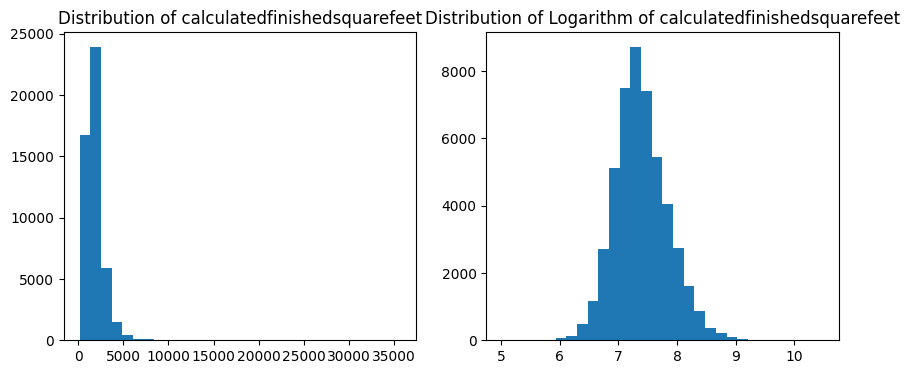

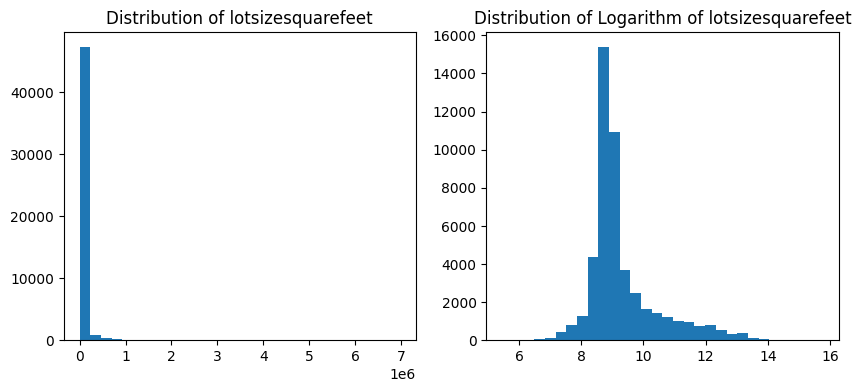

In [ ]:
# log transformation
#setting up df with log transformed predictors
X_train_log_dis = X_train_3f.copy()

X_train_log_dis['calculatedfinishedsquarefeet'] = np.log(X_train_log_dis['calculatedfinishedsquarefeet'])
X_train_log_dis['lotsizesquarefeet'] = np.log(X_train_log_dis['lotsizesquarefeet'])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train_3f['calculatedfinishedsquarefeet'], bins=30)
axes[0].set_title('Distribution of calculatedfinishedsquarefeet')
axes[1].hist(X_train_log_dis['calculatedfinishedsquarefeet'], bins=30)
axes[1].set_title('Distribution of Logarithm of calculatedfinishedsquarefeet')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(X_train_3f['lotsizesquarefeet'], bins=30)
axes[0].set_title('Distribution of lotsizesquarefeet')
axes[1].hist(X_train_log_dis['lotsizesquarefeet'], bins=30)
axes[1].set_title('Distribution of Logarithm of lotsizesquarefeet')
plt.show()


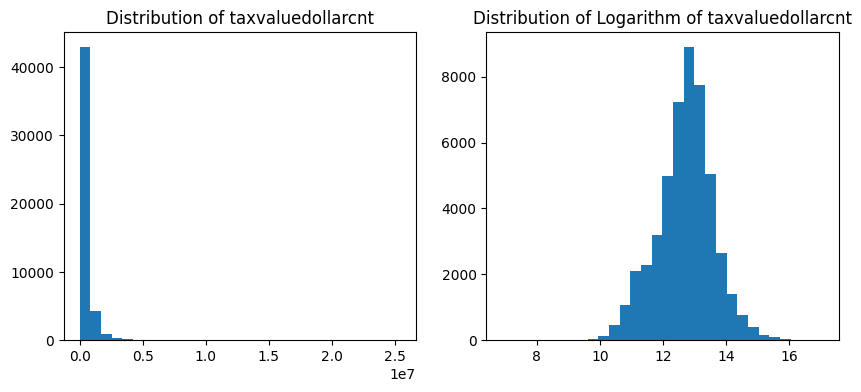

In [ ]:
#setting up log transformed target column

y_train_log_dis = y_train.copy()

y_train_log_dis = np.log(y_train_log_dis)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(y_train, bins=30)
axes[0].set_title('Distribution of taxvaluedollarcnt')
axes[1].hist(y_train_log_dis, bins=30)
axes[1].set_title('Distribution of Logarithm of taxvaluedollarcnt')
plt.show()

log transformation

In [ ]:
#transforming ONLY the target column
from sklearn.compose import TransformedTargetRegressor

X_train_log = X_train_3f.copy()

#linear regression (model_linear1)
model_linear_log = TransformedTargetRegressor(
    regressor=model_linear1,
    func=np.log1p,
    inverse_func=np.expm1)

mae_scores_log_linear = -cross_val_score(
    model_linear_log, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_linear1_cv)

mean_mae_log_linear = np.mean(mae_scores_log_linear)
std_mae_log_linear = np.std(mae_scores_log_linear)


print(f"Mean MAE: ${mean_mae_log_linear:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_linear:,.4f}")
print()
print(f"Difference in log tranformation on target column only Mean MAE to baseline: ${((mean_mae_log_linear - model_linear1_cvmae)):,.4f}")
print(f"Difference in log tranformation on target column only std MAE to baseline: ${((std_mae_log_linear - model_linear1_std)):,.4f}")


#Mean MAE: $1,151,279.2745
#Standard Deviation of MAE: $1,876,475.2850

#Difference in log tranformation on target column only Mean MAE to baseline: $890,853.9513
#Difference in log tranformation on target column only std MAE to baseline: $1,872,818.1976

Mean MAE: $1,151,279.2745
Standard Deviation of MAE: $1,876,475.2850

Difference in log tranformation on target column only Mean MAE to baseline: $890,853.9513
Difference in log tranformation on target column only std MAE to baseline: $1,872,818.1976


In [ ]:
#ridge regression (model_ridge1)
model_ridge_log = TransformedTargetRegressor(
    regressor=model_ridge1,
    func=np.log1p,
    inverse_func=np.expm1)

mae_scores_log_ridge = -cross_val_score(
    model_ridge_log, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_ridge1_cv)

mean_mae_log_ridge = np.mean(mae_scores_log_ridge)
std_mae_log_ridge = np.std(mae_scores_log_ridge)


print(f"Mean MAE: ${mean_mae_log_ridge:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_ridge:,.4f}")
print()
print(f"Difference in log tranformation on target column only Mean MAE to baseline: ${((mean_mae_log_ridge - model_ridge1_cvmae)):,.4f}")
print(f"Difference in log tranformation on target column only std MAE to baseline: ${((std_mae_log_ridge - model_ridge1_std)):,.4f}")



#Mean MAE: $1,149,643.4281
#Standard Deviation of MAE: $1,873,114.8688

#Difference in log tranformation on target column only Mean MAE to baseline: $889,221.8421
#Difference in log tranformation on target column only std MAE to baseline: $1,869,457.1977

Mean MAE: $1,149,643.4281
Standard Deviation of MAE: $1,873,114.8688

Difference in log tranformation on target column only Mean MAE to baseline: $889,221.8421
Difference in log tranformation on target column only std MAE to baseline: $1,869,457.1977


In [ ]:
#random forest regressor (model_forest1)
model_forest_log = TransformedTargetRegressor(
    regressor=model_forest1,
    func=np.log1p,
    inverse_func=np.expm1)

mae_scores_log_forest = -cross_val_score(
    model_forest_log, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_forest1_cv)

mean_mae_log_forest = np.mean(mae_scores_log_forest)
std_mae_log_forest = np.std(mae_scores_log_forest)


print(f"Mean MAE: ${mean_mae_log_forest:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_forest:,.4f}")
print()
print(f"Difference in log tranformation on target column only Mean MAE to baseline: ${((mean_mae_log_forest - model_forest1_cvmae)):,.4f}")
print(f"Difference in log tranformation on target column only std MAE to baseline: ${((std_mae_log_forest - model_forest1_std)):,.4f}")

#Mean MAE: $208,140.4519
#Standard Deviation of MAE: $3,793.7732

#Difference in log tranformation on target column only Mean MAE to baseline: $4,973.9621
#Difference in log tranformation on target column only std MAE to baseline: $-45.8819

Mean MAE: $208,140.4519
Standard Deviation of MAE: $3,793.7732

Difference in log tranformation on target column only Mean MAE to baseline: $4,973.9621
Difference in log tranformation on target column only std MAE to baseline: $-45.8819


In linear regression and ridge regression I found that an exponential increase in MAE could be potentially caused by the model overshooting, the data containing negative values or feature scale discrepancies. If the reason was negative values, due to the longitude I think this jump would be seen in random forest model as well, so I will take that reason out of the equation. So i believe it is caused by an overshoot, a scale discrpancy or a combination of both. A slight overestimation on the log scale can be huge on the original scale, with a difference in scales I will try these models with scaling both the continuous features and the target.

In [ ]:
X_train_3f.columns

Index(['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr',
       'calculatedfinishedsquarefeet', 'fireplacecnt', 'latitude', 'longitude',
       'lotsizesquarefeet', 'poolcnt', 'roomcnt', 'unitcnt', 'yearbuilt',
       'buildingqualitytypeid', 'taxdelinquencyflag',
       'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_10.0',
       'heatingorsystemtypeid_11.0', 'heatingorsystemtypeid_13.0',
       'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_2.0',
       'heatingorsystemtypeid_20.0', 'heatingorsystemtypeid_24.0',
       'heatingorsystemtypeid_6.0', 'heatingorsystemtypeid_7.0',
       'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0',
       'propertylandusetypeid_248.0', 'propertylandusetypeid_260.0',
       'propertylandusetypeid_261.0', 'propertylandusetypeid_263.0',
       'propertylandusetypeid_264.0', 'propertylandusetypeid_265.0',
       'propertylandusetypeid_266.0', 'propertylandusetypeid_267.0',
       'propertylandusetypeid_269.0', 'propertylandusetypei

I am choosing to log transform the continuous features 'calculatedfinsihedsquarefeet' and 'lotsizesquarefeet'. These features have the largest range out of all the features provided in the dataset and are the features that will benefit the most from the transformation

The features that have the next longest range are 'latitude', 'longitude', and 'yearbuilt'; although they have a larger range they will not utilize the log transformation because the information provided will not be interpretable on the log scale. The features will lose the actual distance or chronological meaning, which will not be suffucent for analysis.

'bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'fireplacecnt', 'poolcnt', 'roomcnt', and 'unitcnt' although they are all discrete numerical features (they have a limited range). Using log transformation for these columns can lower interpretability and distort the distribution of the data.

In [ ]:
#transforming both continuous features and the target

#linear regression (model_linear1)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.base import clone

continuous_features = ['calculatedfinishedsquarefeet', 'lotsizesquarefeet']

#going to convert continuous features and predict then convert back to original scale for cv
feature_log_transformer = ColumnTransformer(
    transformers=[
        ('log_X', FunctionTransformer(np.log1p, validate=True), continuous_features),

    ],
    remainder='passthrough'
)

#using pipeline to go through dataset and set transformation
full_feature_pipeline_linear = Pipeline(steps=[
    ('preprocessing', clone(feature_log_transformer)),
    ('regressor', clone(model_linear1))
])

#going to convert target column and predict then convert back to original scale for cv
model_log_all_linear = TransformedTargetRegressor(
    regressor=full_feature_pipeline_linear,
    func=np.log1p,
    inverse_func=np.expm1
)
#repeated 5 fold cv to find mean MAE
mae_scores_log_all_linear = -cross_val_score(
    model_log_all_linear, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_linear1_cv
)

mean_mae_log_all_linear = np.mean(mae_scores_log_all_linear)
std_mae_log_all_linear = np.std(mae_scores_log_all_linear)

print(f"Mean MAE: ${mean_mae_log_all_linear:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_all_linear:,.4f}")
print()
print(f"Difference in log tranformation on continuous features and target Mean MAE to baseline: ${((mean_mae_log_all_linear - model_linear1_cvmae)):,.4f}")
print(f"Difference in log tranformation on continuous features and target std MAE to baseline: ${((std_mae_log_all_linear - model_linear1_std)):,.4f}")


#Mean MAE: $231,960.2949
#Standard Deviation of MAE: $9,837.0601

#Difference in log tranformation on continuous features and target Mean MAE to baseline: $-28,465.0284
#Difference in log tranformation on continuous features and target std MAE to baseline: $6,179.9727

Mean MAE: $231,960.2949
Standard Deviation of MAE: $9,837.0601

Difference in log tranformation on continuous features and target Mean MAE to baseline: $-28,465.0284
Difference in log tranformation on continuous features and target std MAE to baseline: $6,179.9727


In [ ]:
#ridge regression (model_ridge1)

continuous_features = ['calculatedfinishedsquarefeet', 'lotsizesquarefeet']


feature_log_transformer = ColumnTransformer(
    transformers=[
        ('log_X', FunctionTransformer(np.log1p, validate=True,feature_names_out='one-to-one'), continuous_features),

    ],
    remainder='passthrough'
)


full_feature_pipeline_ridge = Pipeline(steps=[
    ('preprocessing', clone(feature_log_transformer)),
    ('regressor', clone(model_ridge1))
])


model_log_all_ridge = TransformedTargetRegressor(
    regressor=full_feature_pipeline_ridge,
    func=np.log1p,
    inverse_func=np.expm1
)


mae_scores_log_all_ridge = -cross_val_score(
    model_log_all_ridge, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_ridge1_cv
)

mean_mae_log_all_ridge = np.mean(mae_scores_log_all_ridge)
std_mae_log_all_ridge = np.std(mae_scores_log_all_ridge)

print(f"Mean MAE: ${mean_mae_log_all_ridge:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_all_ridge:,.4f}")
print()
print(f"Difference in log tranformation on continuous features and target Mean MAE to baseline: ${((mean_mae_log_all_ridge - model_ridge1_cvmae)):,.4f}")
print(f"Difference in log tranformation on continuous features and target std MAE to baseline: ${((std_mae_log_all_ridge - model_ridge1_std)):,.4f}")



#Mean MAE: $231,905.5768
#Standard Deviation of MAE: $9,648.4704

#Difference in log tranformation on continuous features and target Mean MAE to baseline: $-28,516.0092
#Difference in log tranformation on continuous features and target std MAE to baseline: $5,990.7993

Mean MAE: $231,905.5768
Standard Deviation of MAE: $9,648.4704

Difference in log tranformation on continuous features and target Mean MAE to baseline: $-28,516.0092
Difference in log tranformation on continuous features and target std MAE to baseline: $5,990.7993


In [ ]:
#random forest regression (model_forest1)

continuous_features = ['calculatedfinishedsquarefeet', 'lotsizesquarefeet']


feature_log_transformer = ColumnTransformer(
    transformers=[
        ('log_X', FunctionTransformer(np.log1p, validate=True), continuous_features),

    ],
    remainder='passthrough'
)


full_feature_pipeline_forest = Pipeline(steps=[
    ('preprocessing', clone(feature_log_transformer)),
    ('regressor', clone(model_forest1))
])


model_log_all_forest = TransformedTargetRegressor(
    regressor=full_feature_pipeline_forest,
    func=np.log1p,
    inverse_func=np.expm1
)


mae_scores_log_all_forest = -cross_val_score(
    model_log_all_forest, X_train_log, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_forest1_cv
)

mean_mae_log_all_forest = np.mean(mae_scores_log_all_forest)
std_mae_log_all_forest = np.std(mae_scores_log_all_forest)

print(f"Mean MAE: ${mean_mae_log_all_forest:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_log_all_forest:,.4f}")
print()
print(f"Difference in log tranformation on continuous features and target Mean MAE to baseline: ${((mean_mae_log_all_forest - model_forest1_cvmae)):,.4f}")
print(f"Difference in log tranformation on continuous features and target std MAE to baseline: ${((std_mae_log_all_forest - model_forest1_std)):,.4f}")

Mean MAE: $208,111.3938
Standard Deviation of MAE: $3,802.6672

Difference in log tranformation on continuous features and target Mean MAE to baseline: $4,944.9039
Difference in log tranformation on continuous features and target std MAE to baseline: $-36.9879


NORMALIZATION

because the ranges of each feature are significantly different between the continuous, ordinal, and nominal features we will try to scale each feature using the StandardScaler() to see if the model will give a more equal weight to each feature.

In [ ]:
#LINEAR REGRESSION (model_linear1)
from sklearn.pipeline import Pipeline

X_train_scale = X_train_3f.copy()

scaler = StandardScaler()
pipeline_scalar_linear = Pipeline([
    ('normalize', scaler),
    ('regressor', clone(model_linear1))
])
#cross-val
neg_mae_scores_scalar_linear = cross_val_score(
    pipeline_scalar_linear, X_train_scale, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_linear1_cv,
    n_jobs=-1
)

# Convert MAE values and calculate the mean
mae_scores_scalar_linear = -neg_mae_scores_scalar_linear
mean_mae_scalar_linear = np.mean(mae_scores_scalar_linear)
std_mae_scalar_linear = np.std(mae_scores_scalar_linear)


print(f"Mean MAE: ${mean_mae_scalar_linear:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_scalar_linear:,.4f}")
print()
print(f"Difference in scaled Mean MAE to baseline: ${((mean_mae_scalar_linear - model_linear1_cvmae)):,.4f}")
print(f"Difference in scaled std MAE to baseline: ${((std_mae_scalar_linear - model_linear1_std)):,.4f}")



#Mean MAE: $260,424.9487
#Standard Deviation of MAE: $3,657.1894

#Difference in scaled Mean MAE to baseline: $-0.3745
#Difference in scaled std MAE to baseline: $0.1020

Mean MAE: $260,424.9487
Standard Deviation of MAE: $3,657.1894

Difference in scaled Mean MAE to baseline: $-0.3745
Difference in scaled std MAE to baseline: $0.1020


In [ ]:
# ridge regression model (model_ridge1)

pipeline_scalar_ridge = Pipeline([
    ('normalize', scaler),
    ('regressor', clone(model_ridge1))
])


neg_mae_scores_scalar_ridge = cross_val_score(
    pipeline_scalar_ridge, X_train_scale, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_ridge1_cv,
    n_jobs=-1
)


mae_scores_scalar_ridge = -neg_mae_scores_scalar_ridge
mean_mae_scalar_ridge = np.mean(mae_scores_scalar_ridge)
std_mae_scalar_ridge = np.std(mae_scores_scalar_ridge)


print(f"Mean MAE: ${mean_mae_scalar_ridge:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_scalar_ridge:,.4f}")
print()
print(f"Difference in scaled Mean MAE to baseline: ${((mean_mae_scalar_ridge - model_ridge1_cvmae)):,.4f}")
print(f"Difference in scaled std MAE to baseline: ${((std_mae_scalar_ridge - model_ridge1_std)):,.4f}")



#Mean MAE: $260,421.5860
#Standard Deviation of MAE: $3,657.6711

#Difference in scaled Mean MAE to baseline: $0.0000
#Difference in scaled std MAE to baseline: $0.0000

Mean MAE: $260,421.5860
Standard Deviation of MAE: $3,657.6711

Difference in scaled Mean MAE to baseline: $0.0000
Difference in scaled std MAE to baseline: $0.0000


In [ ]:
# random forest regressor (model_forest1)

pipeline_scalar_rf = Pipeline([
    ('normalize', scaler),
    ('regressor', clone(model_forest1))
])


neg_mae_scores_scalar_rf = cross_val_score(
    pipeline_scalar_rf, X_train_scale, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_forest1_cv,
    n_jobs=2    #increase n_jobs since got a user warning error for to short worker timeout or memory leak
)


mae_scores_scalar_rf = -neg_mae_scores_scalar_rf
mean_mae_scalar_rf = np.mean(mae_scores_scalar_rf)
std_mae_scalar_rf = np.std(mae_scores_scalar_rf)


print(f"Mean MAE: ${mean_mae_scalar_rf:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_scalar_rf:,.4f}")
print()
print(f"Difference in scaled Mean MAE to baseline: ${((mean_mae_scalar_rf - model_forest1_cvmae)):,.4f}")
print(f"Difference in scaled std MAE to baseline: ${((std_mae_scalar_rf - model_forest1_std)):,.4f}")



#Mean MAE: $203,182.7569
#Standard Deviation of MAE: $3,787.9190

#Difference in scaled Mean MAE to baseline: $16.2671
#Difference in scaled std MAE to baseline: $-51.7361

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mean MAE: $203,182.7569
Standard Deviation of MAE: $3,787.9190

Difference in scaled Mean MAE to baseline: $16.2671
Difference in scaled std MAE to baseline: $-51.7361


Frequency Encoding

Originally tried binning, but after binning the continuous features the use of one-hot encoding added to may columns and the models took up too make RAM. Instead will look at frequency encoding, so the transformation does not add any extra columns. I am looking at frequency encoding 'latitude', 'longitude', and 'yearbuilt', since these features can not be log transformed.

I looked at feature encoding all continuous features, but it did not help the MAE. I also looked at combining the log transformed columns above with the frequency encoded columns below and that did not improve the model performance either.

In [ ]:
continuous_featuresfe = ['latitude','longitude','yearbuilt']

X_train_frequencyen = X_train_3f.copy()

for c in continuous_featuresfe:
    X_train_frequencyen[c] = X_train_frequencyen[c].astype(str)
    frequency_map = (X_train_frequencyen[c].value_counts(normalize=True))
    X_train_frequencyen[f"{c}_frequency"] = (X_train_frequencyen[c].map(frequency_map))
    X_train_frequencyen = X_train_frequencyen.drop(columns={c})

#LINEAR REGRESSION (model_linear1)

neg_mae_scores_freqen_linear = cross_val_score(
    model_linear1, X_train_frequencyen, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_linear1_cv,
    n_jobs=-1
)


mae_scores_freqen_linear = -neg_mae_scores_freqen_linear
mean_mae_freqen_linear = np.mean(mae_scores_freqen_linear)
std_mae_freqen_linear = np.std(mae_scores_freqen_linear)


print(f"Mean MAE: ${mean_mae_freqen_linear:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_freqen_linear:,.4f}")
print()
print(f"Difference in frequency encoding Mean MAE to baseline: ${((mean_mae_freqen_linear - model_linear1_cvmae)):,.4f}")
print(f"Difference in frequency encoding std MAE to baseline: ${((std_mae_freqen_linear - model_linear1_std)):,.4f}")



#Mean MAE: $264,480.4727
#Standard Deviation of MAE: $3,859.9034

#Difference in scaled Mean MAE to baseline: $4,055.1495
#Difference in scaled std MAE to baseline: $202.8160

Mean MAE: $264,480.4727
Standard Deviation of MAE: $3,859.9034

Difference in frequency encoding Mean MAE to baseline: $4,055.1495
Difference in frequency encoding std MAE to baseline: $202.8160


In [ ]:
X_train_frequencyen[['bathroomcnt', 'bedroomcnt','calculatedbathnbr','calculatedfinishedsquarefeet','fireplacecnt','lotsizesquarefeet','poolcnt','roomcnt', 'unitcnt',
                     'buildingqualitytypeid','latitude_frequency', 'longitude_frequency','yearbuilt_frequency']]

,bathroomcnt,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,fireplacecnt,lotsizesquarefeet,poolcnt,roomcnt,unitcnt,buildingqualitytypeid,latitude_frequency,longitude_frequency,yearbuilt_frequency
61218,2.0,1.0,2.0,853.0,1.0,17794.0,1.0,0.0,1.0,8.0,0.000082,0.001025,0.014435
41849,3.0,3.0,3.0,2072.0,1.0,6161.0,1.0,0.0,1.0,10.0,0.000021,0.000021,0.007217
19719,2.0,2.0,2.0,1281.0,1.0,4851.0,1.0,0.0,1.0,5.0,0.000021,0.000021,0.022902
61520,2.0,3.0,2.0,1278.0,1.0,5829.0,1.0,0.0,1.0,7.0,0.000021,0.000021,0.015050
77279,1.0,1.0,1.0,800.0,1.0,63559.0,1.0,0.0,1.0,6.0,0.000062,0.000513,0.018187
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69442,3.0,3.0,3.0,1560.0,1.0,36537.0,1.0,0.0,1.0,5.0,0.000082,0.000103,0.012507
48765,2.0,3.0,2.0,1337.0,1.0,941489.0,1.0,0.0,1.0,7.0,0.000021,0.000021,0.013225
1126,3.0,2.0,3.0,1220.0,1.0,70345.0,1.0,0.0,1.0,7.0,0.000123,0.000369,0.013225
20233,2.0,3.0,2.0,1140.0,1.0,6901.0,1.0,0.0,1.0,5.0,0.000021,0.000021,0.015050


In [ ]:
#RIDGE REGRESSION

neg_mae_scores_freqen_ridge = cross_val_score(
    model_ridge1, X_train_frequencyen, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_ridge1_cv,
    n_jobs=-1
)


mae_scores_freqen_ridge = -neg_mae_scores_freqen_ridge
mean_mae_freqen_ridge = np.mean(mae_scores_freqen_ridge)
std_mae_freqen_ridge = np.std(mae_scores_freqen_ridge)


print(f"Mean MAE: ${mean_mae_freqen_ridge:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_freqen_ridge:,.4f}")
print()
print(f"Difference in frequency encoding Mean MAE to baseline: ${((mean_mae_freqen_ridge - model_ridge1_cvmae)):,.4f}")
print(f"Difference in frequency encoding std MAE to baseline: ${((std_mae_freqen_ridge - model_ridge1_std)):,.4f}")

#Mean MAE: $264,476.9238
#Standard Deviation of MAE: $3,860.2155

#Difference in frequent encoding Mean MAE to baseline: $4,055.3378
#Difference in frequent encoding std MAE to baseline: $202.5444

Mean MAE: $264,476.9238
Standard Deviation of MAE: $3,860.2155

Difference in frequency encoding Mean MAE to baseline: $4,055.3378
Difference in frequency encoding std MAE to baseline: $202.5444


In [ ]:
#RANDOM FOREST REGRESSOR

neg_mae_scores_freqen_forest = cross_val_score(
    model_forest1, X_train_frequencyen, y_train,
    scoring='neg_mean_absolute_error',
    cv=model_forest1_cv,
    n_jobs=-1
)


mae_scores_freqen_forest = -neg_mae_scores_freqen_forest
mean_mae_freqen_forest = np.mean(mae_scores_freqen_forest)
std_mae_freqen_forest = np.std(mae_scores_freqen_forest)


print(f"Mean MAE: ${mean_mae_freqen_forest:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_freqen_forest:,.4f}")
print()
print(f"Difference in frequency encoding Mean MAE to baseline: ${((mean_mae_freqen_forest - model_forest1_cvmae)):,.4f}")
print(f"Difference in frequency encoding std MAE to baseline: ${((std_mae_freqen_forest - model_forest1_std)):,.4f}")


#Mean MAE: $237,374.0572
#Standard Deviation of MAE: $3,880.8682

#Difference in frequent encoding Mean MAE to baseline: $34,207.5674
#Difference in frequent encoding std MAE to baseline: $41.2131

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Mean MAE: $237,374.0572
Standard Deviation of MAE: $3,880.8682

Difference in frequency encoding Mean MAE to baseline: $34,207.5674
Difference in frequency encoding std MAE to baseline: $41.2131


In [ ]:
mae = {'baseline': [model_linear1_cvmae, model_ridge1_cvmae, model_forest1_cvmae],
    'log target only': [mean_mae_log_linear, mean_mae_log_ridge, mean_mae_log_forest],
'log cont and target' : [mean_mae_log_all_linear, mean_mae_log_all_ridge, mean_mae_log_all_forest],
'normalization': [mean_mae_scalar_linear, mean_mae_scalar_ridge, mean_mae_scalar_rf],
'freq encoding':[mean_mae_freqen_linear, mean_mae_freqen_ridge, mean_mae_freqen_forest]}

df_mae = pd.DataFrame(mae)
model = ['Linear', 'ridge', 'random forest']
df_mae['models'] = [c for c in model]
df_mae = df_mae.set_index('models')
print('MEAN CV MAE:')
df_mae

MEAN CV MAE:


,baseline,log target only,log cont and target,normalization,freq encoding
models,,,,,
Linear,260425.323217,1.151279e+06,231960.294855,260424.948695,264480.472690
ridge,260421.585995,1.149643e+06,231905.576837,260421.585995,264476.923837
random forest,203166.489828,2.081405e+05,208111.393762,203182.756950,237374.057230


In [ ]:
std = {'baseline': [model_linear1_std, model_ridge1_std, model_forest1_std],
    'log target only': [std_mae_log_linear, std_mae_log_ridge, std_mae_log_forest],
'log cont and target' : [std_mae_log_all_linear, std_mae_log_all_ridge, std_mae_log_all_forest],
'normalization': [std_mae_scalar_linear, std_mae_scalar_ridge, std_mae_scalar_rf],
'freq encoding':[std_mae_freqen_linear, std_mae_freqen_ridge, std_mae_freqen_forest]}

print('STD CV MAE')
df_std = pd.DataFrame(std)
model = ['Linear', 'ridge', 'random forest']
df_std['models'] = [c for c in model]
df_std = df_std.set_index('models')
df_std

STD CV MAE


,baseline,log target only,log cont and target,normalization,freq encoding
models,,,,,
Linear,3657.087377,1.876475e+06,9837.060075,3657.189415,3859.903379
ridge,3657.671119,1.873115e+06,9648.470433,3657.671119,3860.215479
random forest,3839.655043,3.793773e+03,3802.667163,3787.918950,3880.868163


### 2.B Discussion

Answer the following questions.

#### 2.B.1

Which of your feature engineering ideas produced the largest improvement in validation performance?

> The feature engineering technique that produced the largest improvement was the log transformation of both the continuous features and target. Although, for our random forest regressor no feature engineering technique lowered the MAE; our baseline model had the best cross validation performance.\
>\
>LINEAR REGRESSION:\
>Log transformation of target only: +\$890,853.9513\
>Log transformation of feature and target: -\$28,465.0284\
>normalization: -\$0.3745\
>frequency encoding: +\$4,055.1495
>
>\
>RIDGE REGRESSION:\
>Log transformation of target only: \$889,221.8421\
>Log transformation of feature and target: -\$28,516.0092\
>normalization: \$0.0000\
>frequency encoding: +\$4,055.3378
>
>\
>RANDOM FOREST REGRESSOR:\
>Log transformation of target only: +\$4,973.9621\
>Log transformation of feature and target: +\$4,944.9039\
>normalization: +\$16.2671\
>frequency encoding: +\$34,207.5674
>
>For our linear and ridge regression models there was a drop of $28,000 for log transformation on both the continuous features and the target. With features such as ‘latitude’, ‘longitude’, and ‘yearbuilt’ it does not make sense to use log transformation because the variables are not interpretable within the log scale, so originally, I thought that frequency encoding these three columns would help bring the MAE down and make a more simplistic model. However, with our chosen feature engineering techniques the largest drop in MAE is when continuous variables ‘calculatedfinishedsquarefeet’ and ‘lotsizesquarefeet’, and the target ‘taxvaluedollarscnt’ are utilizing log transformation.

#### 2.B.2

Were any of your ideas unsuccessful or did they reduce model performance? Briefly explain.

>For the random forest regressor none of the selected feature engineering techniques chosen were able to lower the cross-validation MAE. This could be due to the fact that the trees split data based on thresholds and do not rely on feature scales or linear relationships. Or since we are using MAE as our evaluation metric and it ignores large outlier errors, small improvements from transformed features might not change the final score.
>
>Normalization proved to be ineffective for all three models, as the change in MAE for our linear regression model was only -$0.3745 and there was not change in the ridge regression model. A \$0.00 change in the ridge regression model is expected, since the model starts off using the StandardScalar() during both implementation and .fit() of the baseline model, model_ridge1. However, I found this result for the linear regression model to be surprising, since I thought that arranging all columns to be in the same range would produce a more accurate result instead of automatically giving a higher weight to the features with larger ranges. This showed that our models did not have as much bias as I had previously thought.
>
>Frequency encoding proved to not be ineffective for all three models: linear regression, ridge regression, and random forest regressor. I found this result to be surprising as well since this method helps to maintain the information about the category's prevalence without expanding the feature space like one-hot encoding. Although, in a linear regression model it treats the frequencies as values on a continuous scale, but the actual target values may be completely unrelated to their frequencies. Although as seen below in the feature selection latitude, ‘longitude’, and ‘yearbulit’ were three of the columns that were selected for their importance across all three models. This could be like the log transformation where the actual distance and chronological order was diminished.


#### 2.B.3

Did some models benefit more from feature engineering than others? If so, why do you think this occurred?

>Linear and ridge regression benefitted more from feature engineering than the random forest regressor. Regression assumes that it is working with features that have a normal distribution, so be able to have features simulate this distribution made the model more reliable and accurate.
>
>Linear regression benefited from the most feature engineering techniques, since ridge regression already uses scaling within its original implementation. Linear regression models are highly sensitive to outliers, so feature engineering techniques limit the influence of the outliers, but take the information they provide into account. Random forest regressors are less sensitive to outliers, so the feature engineering techniques do not have as much of an influence than in the regression models


#### 2.B.4

Which preprocessing or feature engineering changes will you keep for the remainder of the milestone? Briefly justify your decision.

> For the remainder of the milestone, we will keep log transformation of both the continuous features ('calculatedfinishedsquarefeet' and 'lotsizesqft') and the target ('taxvaluedollarcnt') for both the linear and ridge regression. This feature engineering technique dropped the cross-validation MAE the most. For the random forest regressor we will keep the baseline model, since none of the feature engineering techniques lowered its MAE.

## Part 3: Refine the Feature Set [6 pts] 

### 3.A Coding

Using your dataset after completing **Part 2** (including any preprocessing and feature engineering changes you decided to keep):

Investigate whether **feature selection** can further improve model performance.

You may use one or more of the following methods:

* Forward Selection (for linear regression models)
* Backward Selection (for linear regression models)
* Feature importance from tree-based models (for decision trees, Random Forests, Bagging, and HistGradientBoosting)
* Another reasonable feature selection method

For each of your three models:

* Select a subset of features using an appropriate feature selection method.
* Retrain the model using only the selected features.
* Evaluate the model using the same repeated cross-validation procedure as before.
* Report the validation performance (the mean and standard deviation of the CV MAE).

> Not every model will necessarily benefit from feature selection. Choose methods that are appropriate for the models you selected. Negative results are valuable if they are carefully evaluated and discussed!

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import ( SequentialFeatureSelector, SelectFromModel )
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

sfs_linear = SequentialFeatureSelector( estimator=model_linear1, n_features_to_select='auto', direction='forward', scoring='neg_mean_absolute_error', cv=5, tol=0.0, n_jobs=2 )

model_linear_selected = Pipeline(steps=[ ('preprocessor', feature_log_transformer), ('feature_selection', sfs_linear), ('regressor', model_linear1) ])

final_model_linear_selected = TransformedTargetRegressor( regressor=model_linear_selected, func=np.log1p, inverse_func=np.expm1 )

mae_scores_selected_linear = -cross_val_score( final_model_linear_selected, X_train_3f, y_train, scoring='neg_mean_absolute_error', cv=model_linear1_cv, n_jobs=2 )

mean_mae_selected_linear = np.mean(mae_scores_selected_linear)
std_mae_selected_linear = np.std(mae_scores_selected_linear)


print("LINEAR REGRESSION WITH FEATURE SELECTION")
print(f"Mean MAE: ${mean_mae_selected_linear:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_selected_linear:,.4f}")
print( f"Difference from Part 2 Mean MAE: " f"${mean_mae_selected_linear - mean_mae_log_all_linear:,.4f}" )
print( f"Difference from Part 2 STD MAE: " f"${std_mae_selected_linear - std_mae_log_all_linear:,.4f}" )
print()


#LINEAR REGRESSION WITH FEATURE SELECTION
#Mean MAE: $230,477.4162
#Standard Deviation of MAE: $4,896.8054
#Difference from Part 2 Mean MAE: $-1,482.8786
#Difference from Part 2 STD MAE: $-4,940.2547

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


LINEAR REGRESSION WITH FEATURE SELECTION
Mean MAE: $230,477.4162
Standard Deviation of MAE: $4,896.8054
Difference from Part 2 Mean MAE: $-1,482.8786
Difference from Part 2 STD MAE: $-4,940.2547



In [ ]:
forward_linear = model_linear_selected.fit(X_train_3f,y_train)
feature_names = forward_linear.named_steps['feature_selection'].get_support()
selected_features_linear = X_train_3f.columns[feature_names]
selected_features_linear


#Index(['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet',
#       'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt',
#       'yearbuilt', 'buildingqualitytypeid', 'taxdelinquencyflag',
#       'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_18.0',
#       'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_7.0',
#       'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0',
#       'propertylandusetypeid_260.0', 'propertylandusetypeid_261.0',
#       'propertylandusetypeid_263.0', 'propertylandusetypeid_265.0'],
#      dtype='object')

Index(['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet',
       'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt',
       'yearbuilt', 'buildingqualitytypeid', 'taxdelinquencyflag',
       'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_18.0',
       'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_7.0',
       'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0',
       'propertylandusetypeid_260.0', 'propertylandusetypeid_261.0',
       'propertylandusetypeid_263.0', 'propertylandusetypeid_265.0'],
      dtype='object')

In [ ]:
#backward selection
from sklearn.feature_selection import ( SequentialFeatureSelector, SelectFromModel )
sfs_linearb = SequentialFeatureSelector( estimator=model_linear1, n_features_to_select='auto', direction='backward', scoring='neg_mean_absolute_error', cv=5, tol=0.0, n_jobs=-1 )

model_linear_selectedb = Pipeline(steps=[ ('preprocessor', clone(feature_log_transformer)), ('feature_selection', sfs_linearb), ('regressor', clone(model_linear1)) ])

final_model_linear_selectedb = TransformedTargetRegressor( regressor=model_linear_selectedb, func=np.log1p, inverse_func=np.expm1 )

mae_scores_selected_linearb = -cross_val_score( final_model_linear_selectedb, X_train_3f, y_train, scoring='neg_mean_absolute_error', cv=model_linear1_cv, n_jobs=-1 )

mean_mae_selected_linearb = np.mean(mae_scores_selected_linearb)
std_mae_selected_linearb = np.std(mae_scores_selected_linearb)

print("LINEAR REGRESSION WITH BACKWARD FEATURE SELECTION")
print(f"Mean MAE: ${mean_mae_selected_linearb:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_selected_linearb:,.4f}")
print( f"Difference from Part 2 Mean MAE: " f"${mean_mae_selected_linearb - mean_mae_log_all_linear:,.4f}" )
print( f"Difference from Part 2 STD MAE: " f"${std_mae_selected_linearb - std_mae_log_all_linear:,.4f}" )
print()



#LINEAR REGRESSION WITH BACKWARD FEATURE SELECTION
#Mean MAE: $229,693.0643
#Standard Deviation of MAE: $4,745.5754
#Difference from Part 2 Mean MAE: $-2,267.2306
#Difference from Part 2 STD MAE: $-5,091.4846


LINEAR REGRESSION WITH BACKWARD FEATURE SELECTION
Mean MAE: $229,693.0643
Standard Deviation of MAE: $4,745.5754
Difference from Part 2 Mean MAE: $-2,267.2306
Difference from Part 2 STD MAE: $-5,091.4846



In [ ]:
backward_linear = model_linear_selectedb.fit(X_train_3f,y_train)
feature_namesb = backward_linear.named_steps['feature_selection'].get_support()
selected_features_linearb = X_train_3f.columns[feature_namesb]
selected_features_linearb




#Index(['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet',
#       'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt',
#       'buildingqualitytypeid', 'heatingorsystemtypeid_1.0',
#       'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_6.0',
#       'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0',
#       'propertylandusetypeid_260.0', 'propertylandusetypeid_263.0',
#       'propertylandusetypeid_265.0', 'propertylandusetypeid_266.0',
#       'propertylandusetypeid_269.0'],
#      dtype='object')

Index(['bathroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet',
       'latitude', 'longitude', 'lotsizesquarefeet', 'poolcnt', 'roomcnt',
       'buildingqualitytypeid', 'heatingorsystemtypeid_1.0',
       'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_6.0',
       'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0',
       'propertylandusetypeid_260.0', 'propertylandusetypeid_263.0',
       'propertylandusetypeid_265.0', 'propertylandusetypeid_266.0',
       'propertylandusetypeid_269.0'],
      dtype='object')

ridge


In [ ]:
# Extract the fitted internal pipeline
model_ridge_feature_im = model_log_all_ridge.fit(
    X_train_log,
    y_train
)
fitted_pipeline = model_ridge_feature_im.regressor_

# Extract the fitted preprocessing and Ridge steps
fitted_preprocessor = fitted_pipeline.named_steps['preprocessing']
fitted_ridge = fitted_pipeline.named_steps['regressor'].named_steps['ridge']

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get Ridge coefficients
coefficients = fitted_ridge.coef_.ravel()

# Verify that the lengths match
print("Number of features:", len(feature_names))
print("Number of coefficients:", len(coefficients))

# Create coefficient table
coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Sort by coefficient importance
coefs = coefs.reindex(
    coefs['Coefficient'].abs().sort_values(ascending=False).index
)

print(coefs)

Number of features: 36
Number of coefficients: 36
                                   Feature  Coefficient
0      log_X__calculatedfinishedsquarefeet     0.416737
2                   remainder__bathroomcnt     0.266781
6                      remainder__latitude    -0.205080
7                     remainder__longitude    -0.140820
3                    remainder__bedroomcnt    -0.135038
4             remainder__calculatedbathnbr    -0.108398
12        remainder__buildingqualitytypeid     0.088117
9                       remainder__roomcnt    -0.030744
11                    remainder__yearbuilt     0.030084
24  remainder__propertylandusetypeid_246.0    -0.024889
26  remainder__propertylandusetypeid_248.0    -0.022372
5                  remainder__fireplacecnt     0.021916
32  remainder__propertylandusetypeid_266.0     0.018772
1                 log_X__lotsizesquarefeet    -0.017680
25  remainder__propertylandusetypeid_247.0    -0.013393
22    remainder__heatingorsystemtypeid_6.0     0.01300

In [ ]:
#RANDOM FOREST REGRESSOR (model_forest1)
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import SelectFromModel
from sklearn.base import clone

#feature importance
X_train_feature_im = X_train_3f.copy()

feature_selector = SelectFromModel(
    estimator=model_forest1,
    threshold="mean")

pipeline_feature_im = Pipeline([
    ('selector', clone(feature_selector)),
    ('regressor', clone(model_forest1))])

mae_scores_feature_im = -cross_val_score(pipeline_feature_im, X_train_feature_im, y_train, scoring='neg_mean_absolute_error', cv=model_forest1_cv)

mean_mae_feature_im = np.mean(mae_scores_feature_im)
std_mae_feature_im = np.std(mae_scores_feature_im)

print(f"Mean MAE: ${mean_mae_feature_im:,.4f}")
print(f"Standard Deviation of MAE: ${std_mae_feature_im:,.4f}")
print()
print(f"Difference in feature importance Mean MAE to baseline: ${((mean_mae_feature_im - model_forest1_cvmae)):,.4f}")
print(f"Difference in feature importance std MAE to baseline: ${((std_mae_feature_im - model_forest1_std)):,.4f}")

#Mean MAE: $203,673.2773
#Standard Deviation of MAE: $3,614.4329

#Difference in both log transformation and binning Mean MAE to baseline: $506.7875
#Difference in both log transformation and binning std MAE to baseline: $-225.2221


Mean MAE: $203,673.2773
Standard Deviation of MAE: $3,614.4329

Difference in feature importance Mean MAE to baseline: $506.7875
Difference in feature importance std MAE to baseline: $-225.2221


In [ ]:
selector_step = pipeline_feature_im.named_steps['selector']
selector_step = selector_step.fit(X_train_feature_im,y_train)

feature_mask = selector_step.get_support()

selected_features = X_train_feature_im.columns[feature_mask]
dropped_features = X_train_feature_im.columns[~feature_mask]


print(f"Total features before selection: {len(X_train_feature_im.columns)}")
print(f"Total features after selection:  {len(selected_features)}\n")

print("SELECTED FEATURES:")
print(list(selected_features))

print("\nDROPPED FEATURES:")
print(list(dropped_features))



#Total features before selection: 36
#Total features after selection:  6

#SELECTED FEATURES:
#['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'yearbuilt', 'buildingqualitytypeid']

#DROPPED FEATURES:
#['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'fireplacecnt', 'poolcnt', 'roomcnt', 'unitcnt', 'taxdelinquencyflag', 'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_10.0', 'heatingorsystemtypeid_11.0', 'heatingorsystemtypeid_13.0', 'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_20.0', 'heatingorsystemtypeid_24.0', 'heatingorsystemtypeid_6.0', 'heatingorsystemtypeid_7.0', 'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0', 'propertylandusetypeid_248.0', 'propertylandusetypeid_260.0', 'propertylandusetypeid_261.0', 'propertylandusetypeid_263.0', 'propertylandusetypeid_264.0', 'propertylandusetypeid_265.0', 'propertylandusetypeid_266.0', 'propertylandusetypeid_267.0', 'propertylandusetypeid_269.0', 'propertylandusetypeid_31.0']

Total features before selection: 36
Total features after selection:  6

SELECTED FEATURES:
['calculatedfinishedsquarefeet', 'latitude', 'longitude', 'lotsizesquarefeet', 'yearbuilt', 'buildingqualitytypeid']

DROPPED FEATURES:
['bathroomcnt', 'bedroomcnt', 'calculatedbathnbr', 'fireplacecnt', 'poolcnt', 'roomcnt', 'unitcnt', 'taxdelinquencyflag', 'heatingorsystemtypeid_1.0', 'heatingorsystemtypeid_10.0', 'heatingorsystemtypeid_11.0', 'heatingorsystemtypeid_13.0', 'heatingorsystemtypeid_18.0', 'heatingorsystemtypeid_2.0', 'heatingorsystemtypeid_20.0', 'heatingorsystemtypeid_24.0', 'heatingorsystemtypeid_6.0', 'heatingorsystemtypeid_7.0', 'propertylandusetypeid_246.0', 'propertylandusetypeid_247.0', 'propertylandusetypeid_248.0', 'propertylandusetypeid_260.0', 'propertylandusetypeid_261.0', 'propertylandusetypeid_263.0', 'propertylandusetypeid_264.0', 'propertylandusetypeid_265.0', 'propertylandusetypeid_266.0', 'propertylandusetypeid_267.0', 'propertylandusetypeid_269.0', 'propertylandu

### 3.B Discussion

#### 3.B.1

Did feature selection improve the validation performance of any of your models?

> Feature selection improved the validation performance of our linear regression model. With forward selection the MAE dropped \$1,482.8786 lower and the standard deviation lowered by \$4,940.2547. In backwards selection the MAE dropped \$2,267.2306 and the standard deviation of the MAE dropped \$5,091.4846. The decrease in the standard deviation is something that our feature engineering techniques were not able to do. In the second section, if the feature engineering technique lowered the MAE there was a trade-off in a slightly higher variance. However, for both forward and backward selection within feature selection there was a slight drop in the MAE, but a significant drop in the standard deviation. By removing the features that were not correlated to the target variable and did not add significant information to the prediction the model became more stable and reliable.
>
>For ridge regression feature selection is not applicable because the model already assigns weights to each feature within the dataset. In this section I have printed out the coefficients of the ridge regression model after it undergoes the log transformation. The model shrinks the weights of less important or correlated features close to zero, but never completely to zero; this process already completes a type of feature selection allowing higher weighted features have more influence within the model than the lower weighted features.
>
>In our random forest regressor model feature selection did not improve the MAE, although there was not a big difference. The MAE was raised by $506.7875 and the standard deviation was dropped by \$225.2221


#### 3.B.2

Were there features that were consistently retained (or consistently removed) across multiple models?

> 'calculatedfinishedsquarefeet'\
>'latitude'\
>'longitude'\
>'lotsizesquarefeet'\
>'yearbuilt'\
>'buildingqualitytypeid'\
These features were consistently retained across all 3 models, including both forward and backward feature selection for linear regression and feature importance for the random forest regressor.\
\
I found it interesting to see that for our linear regression model in both forward and backward selection 'taxdelinquencyflagid' and 'poolcnt' were selected as important features, but in the ridge regression model they both had coefficients of 0.0000 and were not chosen in the random forest regressor feature importance.

#### 3.B.3

Were any of your engineered features selected as important? If so, what does this suggest about the hypotheses you developed in Milestone 1?

> It is interesting to see the continuous variables 'calculatedfinishedsquarefeet' and 'lotsizesquarefeet' consistently picked in both the models effected by the feature engineering techniques and those that were not. In the linear regression model these two log transformed features were selected in both forward and backwards selection. In ridge regression model these log transformed features had some of the highest weight in the coefficients assigned; 'calculatedfinishedsquarefeet' with 0.416737 and 'lotsizesqft' with -0.017680. 'calculatedfinishedsquarefeet' has the highest weight and 'lotsizesquarefeet' is in the top half of important features. Lastly, in the random forest regressor, which does not have any additional influence on the features they were chosen out of only 6 selected features. This leads me to believe that the log transformation used was a benefit to not only lower the cv MAE, but as a way to stabilize the model, since both features follow more of a normal distribution.

#### 3.B.4

After feature selection, did simpler models perform as well as—or better than—the models using the full feature set? Briefly discuss any tradeoffs you observed between model complexity and predictive performance.

>After feature selection, in this project simpler models did perform as well, sometimes slightly better than models using the full feature set. By looking at the feature selection section above the differences were noticeable, but not significantly better than models using the full feature set.
>
>Forward feature selection (linear regression): -\$1,482.8786\
backwards feature selection (Linear Regression): -\$2,267.2306\
feature importance (random forest): +\$506.7875
>
>The main difference seen from feature selection is a significant drop in the standard deviation of the MAE scores.
>
>Forward feature selection (linear regression): -\$4,940.2547\
>backwards feature selection (Linear Regression): -\$5,091.4846\
>feature importance (random forest): -\$225.2221
>
>It looks like a tradeoff of feature engineering and potentially adding complexity to the model was a lower MAE score, but a jump in the standard deviation of the scores; after feature selection it brought the standard deviation back down closer to where it started.
Also, originally in the feature engineering section we had binning as a technique used on the housing dataset. Although it lowered the MAE of the model the complexity of the model increased exponentially, by adding 60+ features to the model. This caused the model and the feature selection to run for hours, often timing out; because of this we had to originally remove other columns that were encoded into 100+ columns to have the model use less RAM. We chose to utilize frequency encoding rather than binning and one-hot encoding to solve this computational problem. An easily identifiable tradeoff of complexity and predictive power is the resource cost; Higher complexity demands significantly more compute power and time for diminishing accuracy gains. Another tradeoff would be the interpretability of the model; A complex model may perform slightly better than more simplistic model, but the interpretability can significantly decrease. With more features there is a better chance of outliers and noise causing the interpretability to lessen.


> Your text here

## Part 4: Tune Your Models [8 pts]

### 4.A Coding

Using the three models developed in **Part 3** (including your final preprocessing, feature engineering, and feature selection decisions):

Investigate whether **hyperparameter tuning** can further improve model performance.

For each of your three models:

* Select one or more important hyperparameters to tune.
* Use one or more appropriate tuning methods. Consider first using validation curves (`sweep_parameter`) to identify a promising region or performance plateau, followed by a focused search using methods such as:

    * GridSearchCV
    * RandomizedSearchCV
    * Another reasonable hyperparameter search method

* Choose hyperparameter values based on the validation results. If several nearby values produce similar validation performance (a performance plateau), prefer **values near the beginning of the plateau,** since they often produce simpler models with nearly identical predictive performance.
* Retrain the model using those hyperparameters.
* Evaluate the tuned model using repeated 5-fold cross-validation (5 repeats).
* Report the validation performance (**mean** and **standard deviation** of the CV MAE).


In [ ]:
# linear regression
# reference: https://sklearner.com/scikit-learn-grid-search-linearregression/

# choose the best Linear Regression model from Part 3
linear_model4 = final_model_linear_selectedb


# hyperparameter tuning: fit_intercept set to both True and False
linear_intercept_dict = {"regressor__regressor__fit_intercept": [True, False]}

linear_intercept_search = GridSearchCV(
    estimator = linear_model4,
    param_grid = linear_intercept_dict,
    scoring = "neg_mean_absolute_error",
    cv = model_linear1_cv,
    n_jobs = -1
)

linear_intercept_search.fit(X_train_3f, y_train)

linear_intercept_best = linear_intercept_search.best_params_["regressor__regressor__fit_intercept"]

print("Best fit_intercept", linear_intercept_best)
print("Linear CV MAE, tuned parameters:", -linear_intercept_search.best_score_)

# re-train the model using the hyperparameters
linear_model_tuned = clone(linear_model4)

linear_model_tuned.set_params(regressor__regressor__fit_intercept = linear_intercept_best)

# evaluate with repeated 5-fold cv
linear_scores_tuned = cross_validate(
    estimator = linear_model_tuned,
    X = X_train_3f,
    y = y_train,
    scoring = "neg_mean_absolute_error",
    cv = model_linear1_cv,
    n_jobs = -1,
    return_train_score = True
)

# report the validation performance: train MAE, CV MAE, and CV STD
linear_tuned_trainmae = -linear_scores_tuned["train_score"].mean()
linear_tuned_cvmae = -linear_scores_tuned["test_score"].mean()
linear_tuned_cvstd = linear_scores_tuned["test_score"].std()


print(f"Tuned Linear fit_intercept: {linear_intercept_best}")
print(f"Tuned Linear Train MAE: {linear_tuned_trainmae:,.2f}")
print(f"Tuned Linear CV MAE: {linear_tuned_cvmae:,.2f}")
print(f"Tuned Linear STD: {linear_tuned_cvstd:,.2f}")

# fit the final tuned model
linear_model_tuned.fit(X_train_3f, y_train)

# Best fit_intercept True
# Linear CV MAE, tuned parameters: 230962.1432223602
# Tuned Linear fit_intercept: True
# Tuned Linear Train MAE: 230,754.38
# Tuned Linear CV MAE: 230,962.14
# Tuned Linear STD: 4,597.11

Best fit_intercept True
Linear CV MAE, tuned parameters: 229693.0642813119
Tuned Linear fit_intercept: True
Tuned Linear Train MAE: 229,242.63
Tuned Linear CV MAE: 229,693.06
Tuned Linear STD: 4,745.58


TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessor',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('log_X',
                                                                                       FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                                           validate=True),
                                                                                       ['calculatedfinishedsquarefeet',
                                                                                        'lotsizesquarefeet'])])),
                                                     ('feature_selection',
                                                      SequentialFeatureSelector(direction='backward',
                                                                                estimator=LinearRegression(),
                                                                                n_jobs=-1,
                                                                                scoring='neg_mean_absolute_error',
                                                                                tol=0.0)),
                                                     ('regressor',
                                                      LinearRegression())]))

In [ ]:
# ridge regression

# pick best model
ridge_model4 = model_log_all_ridge

# hyperparameter tuning: alpha and/or solver
# start with broad alpha parameters
alpha_broad_dict = {"regressor__regressor__ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]}

ridge_alpha_broadsearch = GridSearchCV(
    estimator = ridge_model4,
    param_grid = alpha_broad_dict,
    scoring = "neg_mean_absolute_error",
    cv = model_ridge1_cv,
    n_jobs = -1
)

ridge_alpha_broadsearch.fit(X_train_3f, y_train)

# look at results for all broad hyperparameters we evaluated
ridge_broad_results = pd.DataFrame(ridge_alpha_broadsearch.cv_results_)
ridge_broad_results["cv_mae"] = (-ridge_broad_results["mean_test_score"])
ridge_broad_results["diff_from_best"] = (ridge_broad_results["cv_mae"] - ridge_broad_results["cv_mae"].min())
ridge_broad_results = ridge_broad_results[[
    "param_regressor__regressor__ridge__alpha",
    "cv_mae",
    "std_test_score",
    "diff_from_best",
    "rank_test_score"
]]

ridge_broad_results = ridge_broad_results.sort_values(by =  "cv_mae")
print(ridge_broad_results.to_string(index = False))

print("Best initial alpha: ", ridge_alpha_broadsearch.best_params_["regressor__regressor__ridge__alpha"])
print("Best initial CV MAE: ", -ridge_alpha_broadsearch.best_score_)

#  param_regressor__regressor__ridge__alpha        cv_mae  std_test_score  diff_from_best  rank_test_score
#                                    100.00 229976.752882     4660.224361        0.000000                1
#                                   1000.00 230326.816277     4573.750177      350.063394                2
#                                     10.00 231477.394293     8216.283173     1500.641410                3
#                                      1.00 231905.576837     9648.470433     1928.823955                4
#                                      0.10 231954.560537     9817.912712     1977.807654                5
#                                      0.01 231959.526840     9835.147928     1982.773958                6
# Best initial alpha:  100
# Best initial CV MAE:  229976.7528824955

# based on those results, do a more focused alpha search
alpha_focus_dict = {"regressor__regressor__ridge__alpha": [50, 75, 100, 150, 250, 500, 750]} # fill in based on the broad search

ridge_alpha_focussearch = GridSearchCV(
    estimator = ridge_model4,
    param_grid = alpha_focus_dict,
    scoring = "neg_mean_absolute_error",
    cv = model_ridge1_cv,
    n_jobs = -1
)

ridge_alpha_focussearch.fit(X_train_3f, y_train)

ridge_alpha_best = ridge_alpha_focussearch.best_params_["regressor__regressor__ridge__alpha"]

# # look at results for all focused hyperparameters we evaluated
ridge_focus_results = pd.DataFrame(ridge_alpha_focussearch.cv_results_)
ridge_focus_results["cv_mae"] = (-ridge_focus_results["mean_test_score"])
ridge_focus_results["diff_from_best"] = (ridge_focus_results["cv_mae"] - ridge_focus_results["cv_mae"].min())
ridge_focus_results = ridge_focus_results[[
    "param_regressor__regressor__ridge__alpha",
    "cv_mae",
    "std_test_score",
    "diff_from_best",
    "rank_test_score"
]]

ridge_focus_results = ridge_focus_results.sort_values(by =  "cv_mae")

print(ridge_focus_results.to_string(index = False))
print("Best alpha: ", ridge_alpha_best)
print("CV MAE with Tuned Alpha: ", -ridge_alpha_focussearch.best_score_)

# re-train the model using the hyperparameters
ridge_model_tuned = clone(ridge_model4)

ridge_model_tuned.set_params(regressor__regressor__ridge__alpha = ridge_alpha_best)

# evaluate with repeated 5-fold cv
ridge_scores_tuned = cross_validate(
        estimator = ridge_model_tuned,
        X = X_train_3f,
        y = y_train,
        scoring = "neg_mean_absolute_error",
        cv = model_ridge1_cv,
        n_jobs = -1,
        return_train_score = True
)

# # report the validation performance: train MAE, CV MAE, and CV STD
ridge_tuned_trainmae = -ridge_scores_tuned["train_score"].mean()
ridge_tuned_cvmae = -ridge_scores_tuned["test_score"].mean()
ridge_tuned_cvstd = ridge_scores_tuned["test_score"].std()

print(f"Tuned Ridge Alpha: {ridge_alpha_best}")
print(f"Tuned Ridge Train MAE: {ridge_tuned_trainmae:,.2f}")
print(f"Tuned Ridge CV MAE: {ridge_tuned_cvmae:,.2f}")
print(f"Tuned Ridge STD: {ridge_tuned_cvstd:,.2f}")

# # fit the model
ridge_model_tuned.fit(X_train_3f, y_train)

#  param_regressor__regressor__ridge__alpha        cv_mae  std_test_score  diff_from_best  rank_test_score
#                                       250 229756.317250     4537.861096        0.000000                1
#                                       150 229818.669218     4550.243701       62.351968                2
#                                       500 229894.281859     4558.389022      137.964608                3
#                                       100 229976.752882     4660.224361      220.435632                4
#                                       750 230102.470544     4565.911493      346.153294                5
#                                        75 230143.971632     4856.972030      387.654381                6
#                                        50 230434.017746     5358.754880      677.700495                7
# Best alpha:  250
# CV MAE with Tuned Alpha:  229756.31725044287
# Tuned Ridge Alpha: 250
# Tuned Ridge Train MAE: 229,493.17
# Tuned Ridge CV MAE: 229,756.32
# Tuned Ridge STD: 4,537.86


 param_regressor__regressor__ridge__alpha        cv_mae  std_test_score  diff_from_best  rank_test_score
                                   100.00 229976.752882     4660.224361        0.000000                1
                                  1000.00 230326.816277     4573.750177      350.063394                2
                                    10.00 231477.394293     8216.283173     1500.641410                3
                                     1.00 231905.576837     9648.470433     1928.823955                4
                                     0.10 231954.560537     9817.912712     1977.807654                5
                                     0.01 231959.526840     9835.147928     1982.773958                6
Best initial alpha:  100
Best initial CV MAE:  229976.7528824955
 param_regressor__regressor__ridge__alpha        cv_mae  std_test_score  diff_from_best  rank_test_score
                                      250 229756.317250     4537.861096        0.000000        

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessing',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('log_X',
                                                                                       FunctionTransformer(feature_names_out='one-to-one',
                                                                                                           func=<ufunc 'log1p'>,
                                                                                                           validate=True),
                                                                                       ['calculatedfinishedsquarefeet',
                                                                                        'lotsizesquarefeet'])])),
                                                     ('regressor',
                                                      Pipeline(steps=[('scaler',
                                                                       StandardScaler()),
                                                                      ('ridge',
                                                                       Ridge(alpha=250))]))]))

In [ ]:
# random forest regression

# potential hyperparameters: max_depth, min_samples_leaf, min_samples_split, max_features, n_estimators

# final model
forest_model4 = model_forest1

# start with a broad search of one or two hyperparameters (keep the initial search small because it might take a long time)
forest_broad_dict = {"max_depth": [None, 5, 15, 30],
                     "max_features": ["sqrt", .2, .5, 1.0]}

forest_broad_search = GridSearchCV(
    estimator = forest_model4,
    param_grid = forest_broad_dict,
    scoring = "neg_mean_absolute_error",
    cv = model_forest1_cv,
    n_jobs = -1
)

forest_broad_search.fit(X_train_3f, y_train)

# look at results for all broad hyperparameters we evaluated
forest_broad_results = pd.DataFrame(forest_broad_search.cv_results_)
forest_broad_results["cv_mae"] = (-forest_broad_results["mean_test_score"])
forest_broad_results["diff_from_best"] = (forest_broad_results["cv_mae"] - forest_broad_results["cv_mae"].min())
forest_broad_results = forest_broad_results[[
    "param_max_depth",
    "param_max_features",
    "cv_mae",
    "std_test_score",
    "diff_from_best",
    "rank_test_score"
]]

forest_broad_results = forest_broad_results.sort_values(by =  "cv_mae")
print(forest_broad_results.to_string(index = False))

# identify the values or range with the lowest CV MAE
print("Forest best broad parameters: ", forest_broad_search.best_params_)
print("Forest best broad CV MAE: ", -forest_broad_search.best_score_)

# param_max_depth param_max_features        cv_mae  std_test_score  diff_from_best  rank_test_score
#              15                0.5 202212.555646     3808.991933        0.000000                1
#              15                1.0 202503.656260     3919.291255      291.100614                2
#              30                0.5 202539.344887     3842.153531      326.789241                3
#            None                0.5 202645.394951     3801.919229      432.839305                4
#              30                1.0 203082.689400     3818.852999      870.133754                5
#            None                1.0 203166.489828     3839.655043      953.934182                6
#              30                0.2 203638.489672     3929.480712     1425.934026                7
#            None                0.2 203807.697255     4079.769623     1595.141609                8
#              30               sqrt 204136.378200     4014.914462     1923.822554                9
#            None               sqrt 204230.953441     3970.037271     2018.397795               10
#              15                0.2 205347.792523     3970.618015     3135.236877               11
#              15               sqrt 206150.756874     3971.636255     3938.201228               12
#               5                1.0 229636.471529     3998.537359    27423.915883               13
#               5                0.5 230666.329703     4258.052827    28453.774057               14
#               5                0.2 238565.671628     4336.348968    36353.115982               15
#               5               sqrt 240701.849286     4303.776618    38489.293640               16
# Forest best broad parameters:  {'max_depth': 15, 'max_features': 0.5}
# Forest best broad CV MAE:  202212.5556459813

# based on the broad-search results, perform a more focused search
forest_focus_dict = {"max_depth": [10, 15, 20],
                     "max_features": [0.4, 0.5, 0.6]}

forest_focus_search = GridSearchCV(
    estimator = forest_model4,
    param_grid = forest_focus_dict,
    scoring = "neg_mean_absolute_error",
    cv = model_forest1_cv,
    n_jobs = -1
)

forest_focus_search.fit(X_train_3f, y_train)

# look at results for all focused hyperparameters we evaluated
forest_focus_results = pd.DataFrame(forest_focus_search.cv_results_)
forest_focus_results["cv_mae"] = (-forest_focus_results["mean_test_score"])
forest_focus_results["diff_from_best"] = (forest_focus_results["cv_mae"] - forest_focus_results["cv_mae"].min())
forest_focus_results = forest_focus_results[[
    "param_max_depth",
    "param_max_features",
    "cv_mae",
    "std_test_score",
    "diff_from_best",
    "rank_test_score"
]]

forest_focus_results = forest_focus_results.sort_values(by =  "cv_mae")
print(forest_focus_results.to_string(index = False))

print("Forest best focused parameters: ", forest_focus_search.best_params_)
print("Forest best focused CV MAE: ", -forest_focus_search.best_score_)

# re-train the model using the hyperparameters
forest_model_tuned = clone(forest_model4)
forest_model_tuned.set_params(**forest_focus_search.best_params_)

# evaluate with repeated 5-fold cv
forest_scores_tuned = cross_validate(
    estimator = forest_model_tuned,
    X = X_train_3f,
    y = y_train,
    scoring = "neg_mean_absolute_error",
    cv = model_forest1_cv,
    n_jobs = -1,
    return_train_score = True
)

# report the validation performance: train MAE, CV MAE, and CV STD
forest_tuned_trainmae = -forest_scores_tuned["train_score"].mean()
forest_tuned_cvmae = -forest_scores_tuned["test_score"].mean()
forest_tuned_cvstd = forest_scores_tuned["test_score"].std()

print(f"Tuned Forest Params: {forest_focus_search.best_params_}")
print(f"Tuned Forest Train MAE: {forest_tuned_trainmae:,.2f}")
print(f"Tuned Forest CV MAE: {forest_tuned_cvmae:,.2f}")
print(f"Tuned Forest STD: {forest_tuned_cvstd:,.2f}")

# fit the final model
forest_model_tuned.fit(X_train_3f, y_train)

# param_max_depth  param_max_features        cv_mae  std_test_score  diff_from_best  rank_test_score
#               20                 0.5 201725.501967     3898.716968        0.000000                1
#               20                 0.6 201810.270745     3786.420342       84.768778                2
#               20                 0.4 202020.233298     3975.135537      294.731331                3
#               15                 0.5 202212.555646     3808.991933      487.053679                4
#               15                 0.6 202287.446698     3803.431052      561.944731                5
#               15                 0.4 202920.212865     3913.817515     1194.710899                6
#               10                 0.6 207894.864873     3901.093452     6169.362906                7
#               10                 0.5 208340.773818     3846.250224     6615.271851                8
#               10                 0.4 209419.712121     4063.678598     7694.210154                9
# Forest best focused parameters:  {'max_depth': 20, 'max_features': 0.5}
# Forest best focused CV MAE:  201725.5019667827
# Tuned Forest Params: {'max_depth': 20, 'max_features': 0.5}
# Tuned Forest Train MAE: 106,016.50
# Tuned Forest CV MAE: 201,725.50
# Tuned Forest STD: 3,898.72

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


param_max_depth param_max_features        cv_mae  std_test_score  diff_from_best  rank_test_score
             15                0.5 202212.555646     3808.991933        0.000000                1
             15                1.0 202503.656260     3919.291255      291.100614                2
             30                0.5 202539.344887     3842.153531      326.789241                3
           None                0.5 202645.394951     3801.919229      432.839305                4
             30                1.0 203082.689400     3818.852999      870.133754                5
           None                1.0 203166.489828     3839.655043      953.934182                6
             30                0.2 203638.489672     3929.480712     1425.934026                7
           None                0.2 203807.697255     4079.769623     1595.141609                8
             30               sqrt 204136.378200     4014.914462     1923.822554                9
           None     

RandomForestRegressor(max_depth=20, max_features=0.5, random_state=42)

# Linear Regression

*   Best fit_intercept True
*   Linear CV MAE, tuned parameters: 230962.1432223602
*   Tuned Linear fit_intercept: True
*   Tuned Linear Train MAE: 230,754.38
*   Tuned Linear CV MAE: 230,962.14
*   Tuned Linear STD: 4,597.11

# Ridge

Broad Search
*   Best initial alpha:  100
*   Best initial CV MAE:  229976.7528824955

Alpha 100
*   cv_mae  std: 229976.75
*   std_test_score: 4660.22
*   test_score  diff_from_best: 0
*   rank_test_score: 1
*   Best cv_mae

Alpha 1000
*   cv_mae  std: 230326.82
*   std_test_score: 4573.75
*   test_score  diff_from_best: 350.06
*   rank_test_score: 2

Alpha 10
*   cv_mae  std: 231477.39
*   std_test_score: 8216.28
*   test_score  diff_from_best: 1500.64
*   rank_test_score: 3

Alpha 1
*   cv_mae  std: 231905.58
*   std_test_score: 9648.47
*   test_score  diff_from_best: 1928.82
*   rank_test_score: 4

Alpha 0.1
*   cv_mae  std: 231954.56
*   std_test_score: 9817.91
*   test_score  diff_from_best: 1977.81
*   rank_test_score: 5

Alpha 0.01
*   cv_mae  std: 231959.53
*   std_test_score: 9,835.15
*   test_score  diff_from_best: 1982.77
*   rank_test_score: 6


Focused Search


*   CV MAE with Tuned Alpha:  229756.31725044287
*   Tuned Ridge Train MAE: 229,493.17
*   Tuned Ridge CV MAE: 229,756.32
*   Tuned Ridge STD: 4,537.86

Alpha 250
*   cv_mae  std: 229756.32
*   std_test_score: 4537.86
*   test_score  diff_from_best: 0
*   rank_test_score: 1
*   Best CV MAE
*   Best STD

Alpha 150
*   cv_mae  std: 229818.67
*   std_test_score: 4550.24
*   test_score  diff_from_best: 62.35
*   rank_test_score: 2

Alpha 500
*   cv_mae  std: 229894.28
*   std_test_score: 4558.39
*   test_score  diff_from_best: 137.96
*   rank_test_score: 3

Alpha 100
*   cv_mae  std: 229976.75
*   std_test_score: 4660.22
*   test_score  diff_from_best: 220.44
*   rank_test_score: 4

Alpha 750
*   cv_mae  std: 230102.47
*   std_test_score: 4565.91
*   test_score  diff_from_best: 346.15
*   rank_test_score: 5

Alpha 75
*   cv_mae  std: 230143.97
*   std_test_score: 4856.97
*   test_score  diff_from_best: 387.65
*   rank_test_score: 6

Alpha 50
*   cv_mae  std: 230434.02
*   std_test_score: 5358.75
*   test_score  diff_from_best: 677.7
*   rank_test_score: 7

# Random Forest


Broad Search
*   Best 'max_depth': 15
*   Best 'max_features': 0.5
*   Best CV MAE:  202212.5556459813

Top 5 tree results

Tree 1
*   Max Depth: 15
*   Max Features: 0.5
*   CV MAE: 202212.56
*   CV STD: 3808.99
*   Difference from Best: 0
*   Rank:  1
*   Lowest CV MAE

Tree 2
*   Max Depth: 15
*   Max Features: 1
*   CV MAE: 202503.66
*   CV STD: 3919.29
*   Difference from Best: 291.1
*   Rank:  2

Tree 3
*   Max Depth: 30
*   Max Features: 0.5
*   CV MAE: 202539.34
*   CV STD: 3842.15
*   Difference from Best: 326.79
*   Rank:  3

Tree 4
*   Max Depth: None
*   Max Features: 0.5
*   CV MAE: 202645.39
*   CV STD: 3801.92
*   Difference from Best: 432.84
*   Rank:  4
*   Lowest STD

Tree 5
*   Max Depth: 30
*   Max Features: 1
*   CV MAE: 203082.69
*   CV STD: 3818.85
*   Difference from Best: 870.13
*   Rank:  5

Worst Tree
*   Max Depth: 5
*   Max Features: sqrt
*   CV MAE: 240701.85
*   CV STD: 4303.78
*   Difference from Best: 38489.29
*   Rank:  16

Focused Search

*   Best 'max_depth': 20
*   Best 'max_features': 0.5
*   Best CV MAE: $201,725.50

Top 5 tree results

Tree 1
*   Max Depth: 20
*   Max Features: 0.5
*   CV MAE: 201725.5
*   CV STD: 3898.72
*   Difference from Best: 0
*   Rank:  1

Tree 2
*   Max Depth: 20
*   Max Features: 0.6
*   CV MAE: 201810.27
*   CV STD: 3786.42
*   Difference from Best: 84.77
*   Rank:  2

Tree 3
*   Max Depth: 20
*   Max Features: 0.4
*   CV MAE: 202020.23
*   CV STD: 3975.14
*   Difference from Best: 294.73
*   Rank:  3

Tree 4
*   Max Depth: 15
*   Max Features: 0.5
*   CV MAE: 202212.56
*   CV STD: 3808.99
*   Difference from Best: 487.05
*   Rank:  4

Tree 5
*   Max Depth: 15
*   Max Features: 0.6
*   CV MAE: 202287.45
*   CV STD: 3803.43
*   Difference from Best: 561.94
*   Rank:  5

Worst Tree
*   Max Depth: 10
*   Max Features: 0.4
*   CV MAE: 209419.71
*   CV STD: 4063.68
*   Difference from Best: 7694.21
*   Rank: 9

Random forest - general conclusion
*   **When compared to the train MAE, random forest consistently overfit**


In [ ]:
# running overnight, save all final Part 4 model results locally

part4_results = pd.DataFrame([
    {
        "model": "Linear Regression",
        "best_parameters": "fit_intercept=True",
        "train_mae": linear_tuned_trainmae,
        "cv_mae": linear_tuned_cvmae,
        "cv_std": linear_tuned_cvstd
    },
    {
        "model": "Ridge Regression",
        "best_parameters": f"alpha={ridge_alpha_best}",
        "train_mae": ridge_tuned_trainmae,
        "cv_mae": ridge_tuned_cvmae,
        "cv_std": ridge_tuned_cvstd
    },
    {
        "model": "Random Forest",
        "best_parameters": str(forest_focus_search.best_params_),
        "train_mae": forest_tuned_trainmae,
        "cv_mae": forest_tuned_cvmae,
        "cv_std": forest_tuned_cvstd
    }
])

part4_results.to_csv(
    "/content/part4_final_results.csv",
    index=False
)

ridge_broad_results.to_csv(
    "/content/ridge_broad_results.csv",
    index=False
)

ridge_focus_results.to_csv(
    "/content/ridge_focus_results.csv",
    index=False
)

forest_broad_results.to_csv(
    "/content/forest_broad_results.csv",
    index=False
)

forest_focus_results.to_csv(
    "/content/forest_focus_results.csv",
    index=False
)

from google.colab import files

files.download("/content/part4_final_results.csv")
files.download("/content/ridge_broad_results.csv")
files.download("/content/ridge_focus_results.csv")
files.download("/content/forest_broad_results.csv")
files.download("/content/forest_focus_results.csv")

print("All Part 4 results were created and download requests were started.")

### 4.B Discussion

Answer the following questions.

#### 4.B.1

Which hyperparameters had the greatest impact on model performance? Briefly explain.

> Max depth in the random forest model had the overall greatest impact on model performance. Through all the iterations of max depth exploration, the CV MAE varied between 201k to 240k showing that it has a substantial impact on this metric. However, we did also calculate the train MAE for each model and that metric indicates there may be overfitting present in this model type which is consistent with earlier results.

> In the Ridge model, tuning the alpha had a small but noticeable impact on CV MAE performance. At alpha 0.01 the CV MAE was 231,960 whereas at alpha 250 the reporteed CV MAE was 229,756 showing an improvement of about 2,000.

#### 4.B.2

Did hyperparameter tuning substantially improve the performance of all three models, or only some of them?

> Hyperparameter tuning of the standard Linear regression actually resulted in a slightly worse CV MAE than shown in part 3. Compared to other model types though, there were much more limited options for tuning Linear Regressions. There was little evidence of the tuning causing either over or underfitting as the train MAE was very close to the CV MAE.

> Ridge Regression showed a modest improvement from part 3 with its CV MAE improving by about 2000. Both the train and test MAE in part 4 were very similar suggesting that the model was stable.

> The random forest model, similarly only had a modest improvement in CV MAE from part 3 with a difference only about 2000. However, when compared to the train MAE from hyperparameter tuning, it seems that there was substantial overfitting (201k CV MAE vs. 106k train MAE)

#### 4.B.3

Which tuning method(s) did you use for each model? Briefly explain why you chose those methods.

> In contrast to other model types, Linear Regression does not provide many opportunities for hyperparameter tuning. We chose to focus on fit_intercept to see if the model estimating an intercept would impact performance.

> We decided to focus on tuning alpha for the Ridge Regression as that controls the amount of regularization. We began with a broad search of alpha values whose results we used to guide us in a more focused search.

> Random Forest models provide several opportunities for hyperparameter tuning. As our baseline random forest showed signs of overfitting, we decided hoped that tuning max depth and max features may help to bridge the gap between the train and test MAEs. We began with a broad search with iterations varying between shallow to deep trees utilizing both small subsets of the features or all the features. We then used the results of that broad search to guide a more focused search of those parameters. Unfortunately this tuned model still showed signs of overfitting.

> To maintain consistency, repeated cross-fold validation was performed on all tuned models. Both the ridge and random forest models utilized gridsearchsv to conduct broad and focused searches.

#### 4.B.4

After tuning, how did the relative performance of your three models change? Did tuning affect which model appeared to perform best?

> Part 3's CV MAE's indicated the random forest model was best, followed by ridge and linear regression. The tuning in part 4 resulted in the same model ranking for CV MAE. Random forest and ridge models only showed a modest improvement from part 3 and the linear model performed slightly worse. Basing model choices solely from CV MAE may be short-sighted though and the train MAE and STD should also be considered. Inspection of the STDs shows that model performance appeared to be relatively stable, with the random forest having the lowest STD by about 700. The train MAE sheds the most light on model performance though - the linear and ridge models had very similar MAEs each only differing between train and cv by less than 300. The random forest model; however, showed a differents of 95k between train and test mae.

> **On first glance, the Random Forest model performed best based on its CV MAE, but when all 3 metrics (train MAE, CV MAE, and STD) are taken into account, the Ridge model was the most balanced.**

## Part 5: Final Model and Workflow Assessment [14 pts] 

### 5.A Coding

Using the work completed in **Parts 1–4**:

Select your **best-performing model** and prepare your final modeling pipeline.

Your pipeline should include all preprocessing, feature engineering, feature selection, and hyperparameter tuning decisions that you chose to retain.

Evaluate your final model by:

* Training on the complete training dataset.
* Reporting the **mean** and **standard deviation** of the repeated cross-validation MAE.
* Evaluating the model on the held-out test set.
* Reporting the final test MAE.

In [ ]:
# Final Linear Regression

final_linear_pipeline = Pipeline(steps=[
    ('preprocessing', clone(feature_log_transformer)),
    ('feature_selection', clone(sfs_linearb)),
    ('regressor', LinearRegression(fit_intercept=True))
])

final_linear_model = TransformedTargetRegressor(
    regressor=final_linear_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Final Ridge Regression
final_ridge_pipeline = Pipeline(steps=[
    ('preprocessing', clone(feature_log_transformer)),
    ('regressor', Ridge(alpha=250))
])

final_ridge_model = TransformedTargetRegressor(
    regressor=final_ridge_pipeline,
    func=np.log1p,
    inverse_func=np.expm1
)

# Final Random Forest Regressor
final_forest_model = RandomForestRegressor(random_state=random_state)

final_candidates = {
    "Linear Regression": final_linear_model,
    "Ridge Regression": final_ridge_model,
    "Random Forest": final_forest_model
}

#Confirm each candidate's CV performance
final_cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=random_state)

final_results = {}

for name, model in final_candidates.items():
    scores = cross_validate(
        model, X_train_3f, y_train,
        cv=final_cv,
        scoring="neg_mean_absolute_error",
        return_train_score=True,
        n_jobs=-1
    )
    train_mae = -scores["train_score"].mean()
    cv_mae = -scores["test_score"].mean()
    cv_std = scores["test_score"].std()

    final_results[name] = {
        "train_mae": train_mae,
        "cv_mae": cv_mae,
        "cv_std": cv_std
    }

    print(f"{name}")
    print(f"  Train MAE: ${train_mae:,.2f}")
    print(f"  CV MAE:    ${cv_mae:,.2f}")
    print(f"  CV STD:    ${cv_std:,.2f}\n")

final_results_df = pd.DataFrame(final_results).T
final_results_df

# Select the best-performing candidate by mean CV MAE
best_model_name = final_results_df["cv_mae"].astype(float).idxmin()
best_model = final_candidates[best_model_name]

print(f"Selected final model: {best_model_name}")

# Train the selected model on the full training set
best_model.fit(X_train_3f, y_train)

# Evaluation
y_test_pred = best_model.predict(X_test_3f)
final_test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\nFinal model: {best_model_name}")
print(f"Final Train MAE:         ${final_results[best_model_name]['train_mae']:,.2f}")
print(f"Final CV MAE (mean):     ${final_results[best_model_name]['cv_mae']:,.2f}")
print(f"Final CV MAE (std):      ${final_results[best_model_name]['cv_std']:,.2f}")
print(f"Final held-out test MAE: ${final_test_mae:,.2f}")

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Linear Regression
  Train MAE: $229,242.63
  CV MAE:    $229,693.06
  CV STD:    $4,745.58

Ridge Regression
  Train MAE: $230,051.81
  CV MAE:    $230,139.58
  CV STD:    $4,632.91

Random Forest
  Train MAE: $76,334.87
  CV MAE:    $203,166.49
  CV STD:    $3,839.66

Selected final model: Random Forest

Final model: Random Forest
Final Train MAE:         $76,334.87
Final CV MAE (mean):     $203,166.49
Final CV MAE (std):      $3,839.66
Final held-out test MAE: $203,910.90


### 5.B Discussion

Answer the following questions.

#### 5.B.1

Compare the performance of your final model with its original baseline from **Part 1**. Which changes contributed the most to the improvement?

> Our final model, the Random Forest Regressor, achieved a held-out test MAE of approximately 203,000, which is nearly identical to its Part 1 baseline CV MAE of 203,166.49. In contrast, Linear and Ridge Regression models improved significantly, reducing their CV MAE from 260,000 to about 230,000 through log transformation, backward feature selection, and hyperparameter tuning. These same techniques did not benefit the Random Forest; log transforms, feature selection, and initial hyperparameter tuning either had no effect or slightly worsened its CV MAE. As a result, most of the performance gains in this milestone are attributed to Linear and Ridge models. The Random Forest likely reached its optimal performance in Part 1, as tree-based models do not depend on linear relationships or normally distributed features as Linear and Ridge models do.

#### 5.B.2

Looking back at the hypotheses you proposed in **Milestone 1**, which were supported by your experimental results? Were any hypotheses disproved?

> Our hypothesis about skewed distributions held up well. We had proposed that the heavy right-skew in calculatedfinishedsquarefeet, lotsizesquarefeet, and the target taxvaluedollarcnt was hurting the linear models, and log-transforming all three dropped CV MAE for both Linear and Ridge Regression. The results of this milestone matched our expectations going in.

> Other hypotheses didn't pan out the way we expected. We had thought standardizing the features would help the linear models by preventing large-range features from dominating the fit, but normalization changed CV MAE by less than 1 for Linear Regression and exactly 0 for Ridge Regression. We also expected frequency encoding of latitude, longitude, and yearbuilt to preserve useful signal more efficiently than one-hot encoding would, but it actually increased CV MAE by roughly $4,000–$34,000 across all three models. We assumed our feature engineering ideas would help the Random Forest as much as the linear models, but none of them did, which reinforced that tree ensembles are largely indifferent to feature scale and skew in a way our linear models were not. Overall, this milestone has confirmed our intuition that distribution shape matters for linear models, but corrected our assumptions about scaling and encoding schemes.

#### 5.B.3

Why did you select this model as your final model? Discuss both its predictive performance and any other considerations (such as stability, simplicity, or interpretability).

> We selected the Random Forest Regressor because it had the lowest cross-validation MAE of the three models, around 203,000 compared to about 230,000 for the tuned Linear and Ridge models. No amount of extra preprocessing, feature selection, or tuning could close this $27,000 gap for the linear models. Although the Random Forest showed some overfitting, was harder to interpret, and needed more computing power, its strong predictive accuracy and consistent cross-validation results matched the main goal for this milestone. We decided that the gain in accuracy was more important than the concerns about interpretability and overfitting.

#### 5.B.4

What did you learn about your dataset and the machine learning process through this end-to-end modeling workflow? If you had additional time, what would you investigate next?

>  The main takeaway from this milestone was that preprocessing and feature engineering do not always help every model. For example, the log transform improved Linear and Ridge models, but it did not help Random Forest, and frequency encoding actually made all models worse. This showed us that we need to check feature engineering choices for each model instead of applying them the same way to all models. We also found that feature selection can lower variance, as seen by a big drop in standard deviation for backward-selected Linear Regression, even if the average CV MAE only improves a little. If we had more time, we could tune the Random Forest's n_estimators, max_depth, and min_samples_leaf more carefully to reduce the gap between train and CV MAE and help prevent overfitting. We could also try HistGradientBoostingRegressor, since it can handle missing values and categorical splits on its own and might reduce overfitting. The last method we could investigate is  to look for better ways to encode latitude and longitude, such as spatial clustering or smoothed target encoding, because frequency encoding did not work well for those columns.